# Supplier characteristics and Scope 3 upstream reductions

This notebook relates firm-level Scope 3 upstream absolute-emissions reductions to the size, composition, emissions profile, ESG performance, and policy adoption of each firm's Tier-1 supplier base. The unit of analysis is the focal-company year. Supplier relationships are already aggregated in the summary file, keeping the analysis memory-safe.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

warnings.filterwarnings('ignore', message='.*DataFrame columns are not unique.*')
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / 'data').exists()
)
SUPPLIER_SUMMARY_PATH = PROJECT_ROOT / 'data/processed/supplier_factset_lseg/company_year_supplier_summary.csv'
MATCHED_PANEL_PATH = PROJECT_ROOT / 'data/processed/cdp_trucost_factset_common/trucost_lseg_factset_matched_2015_2025.csv.gz'
OUTPUT_DIR = PROJECT_ROOT / 'data/outputs/dataset_readers/supplier_scope3_reductions'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Match notebook 07: 2015 supplies lags; ESG-complete 2016--2024 are outcomes.
PANEL_YEARS = set(range(2015, 2025))
ANALYSIS_YEARS = list(range(2016, 2025))
COMPANY_ID = 'company_id'
FACTSET_COMPANY_ID = 'factset_entity_id'
SCOPE3_COLUMN = 'scope_3_upstream_emissions'

if not SUPPLIER_SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Supplier summary not found: {SUPPLIER_SUMMARY_PATH}')
if not MATCHED_PANEL_PATH.exists():
    raise FileNotFoundError(f'Matched panel not found: {MATCHED_PANEL_PATH}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Outputs: {OUTPUT_DIR}')

Project root: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code
Outputs: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\data\outputs\supplier_scope3_reductions


## Load the supplier summary and only required focal-firm fields

The relationship-level detail file is not loaded. It is available for later drill-downs, but is unnecessary for the firm-year analysis.

In [3]:
supplier = pd.read_csv(SUPPLIER_SUMMARY_PATH, low_memory=False)
supplier.columns = supplier.columns.str.strip()
supplier['year'] = pd.to_numeric(supplier['year'], errors='coerce').astype('Int64')
supplier = supplier.rename(columns={'company_id': FACTSET_COMPANY_ID})
supplier[FACTSET_COMPANY_ID] = supplier[FACTSET_COMPANY_ID].astype('string').str.strip()

firm_columns = [
    'year', 'trucost_company_id', 'factset_entity_id', 'factset_name', 'trucost_name', 'lseg_name',
    SCOPE3_COLUMN, 'scope_1_emissions', 'scope_2_emissions',
    'trucost_revenue', 'lseg_revenue', 'esg_score', 'number_of_employees',
    'lseg_name_score', 'factset_name_score', 'isin',
]
available_firm_columns = pd.read_csv(MATCHED_PANEL_PATH, compression='gzip', nrows=0).columns
firm_columns = [column for column in firm_columns if column in available_firm_columns]
if SCOPE3_COLUMN not in firm_columns or 'factset_entity_id' not in firm_columns:
    raise KeyError('The matched panel must contain factset_entity_id and scope_3_upstream_emissions.')

firm = pd.read_csv(MATCHED_PANEL_PATH, compression='gzip', usecols=firm_columns, low_memory=False)
firm['year'] = pd.to_numeric(firm['year'], errors='coerce').astype('Int64')
firm = firm.loc[firm['year'].isin(PANEL_YEARS)].copy()
firm['esg_score'] = pd.to_numeric(firm['esg_score'], errors='coerce')

# Exact notebook-07 base selection: one Trucost company-year, resolved by match quality.
firm['_lseg_match_score'] = pd.to_numeric(firm.get('lseg_name_score'), errors='coerce')
firm['_factset_match_score'] = pd.to_numeric(firm.get('factset_name_score'), errors='coerce')
firm['_isin_sort'] = firm.get('isin', pd.Series('', index=firm.index)).astype('string').fillna('')
firm = (firm.sort_values(
    ['trucost_company_id', 'year', '_lseg_match_score', '_factset_match_score', '_isin_sort'],
    ascending=[True, True, False, False, True], na_position='last',
).drop_duplicates(['trucost_company_id', 'year'], keep='first'))

# Preserve Notebook 07's Trucost-company identifier and its full base sample.
# Supplier characteristics are attached by FactSet entity without collapsing
# distinct Trucost companies that map to the same FactSet entity.
firm = firm.rename(columns={'trucost_company_id': COMPANY_ID})
firm[COMPANY_ID] = firm[COMPANY_ID].astype('string').str.strip()
firm[FACTSET_COMPANY_ID] = firm[FACTSET_COMPANY_ID].astype('string').str.strip()
firm = firm.drop(columns=['_lseg_match_score', '_factset_match_score', '_isin_sort'])
panel = firm.merge(
    supplier, on=[FACTSET_COMPANY_ID, 'year'], how='left', validate='many_to_one'
)
base_sample_mask = panel['year'].isin(ANALYSIS_YEARS) & panel['esg_score'].notna()
base_sample_counts = panel.loc[base_sample_mask].groupby('year').size().reindex(ANALYSIS_YEARS, fill_value=0)
expected_base_counts = pd.Series(
    [3584, 4250, 5349, 5948, 6810, 7645, 8216, 8893, 9899],
    index=ANALYSIS_YEARS,
)
if not base_sample_counts.equals(expected_base_counts):
    raise ValueError(f'Notebook 07 base-sample mismatch:\n{base_sample_counts}')
supplier_covered = base_sample_mask & panel['number_of_tier_1_suppliers'].notna()
scope3_covered = base_sample_mask & panel[SCOPE3_COLUMN].notna()
print(f'Notebook-07 base company-years: {int(base_sample_counts.sum()):,}')
print(f'Notebook-07 base focal companies: {panel.loc[base_sample_mask, COMPANY_ID].nunique():,}')
print(f'Supplier coverage in the base sample: {supplier_covered.sum():,} of {base_sample_mask.sum():,} ({supplier_covered.sum() / base_sample_mask.sum():.1%})')
print(f'Scope 3 upstream coverage in the base sample: {scope3_covered.sum():,} of {base_sample_mask.sum():,} ({scope3_covered.sum() / base_sample_mask.sum():.1%})')
display(base_sample_counts.rename('company_year_observations').to_frame())
#display(panel[[COMPANY_ID, 'year', 'company_name', SCOPE3_COLUMN]].head())

Notebook-07 base company-years: 60,594
Notebook-07 base focal companies: 11,595
Supplier coverage in the base sample: 30,993 of 60,594 (51.1%)
Scope 3 upstream coverage in the base sample: 60,520 of 60,594 (99.9%)


,company_year_observations
year,
2016,3584
2017,4250
2018,5349
2019,5948
2020,6810
2021,7645
2022,8216
2023,8893
2024,9899


## Construct annual absolute Scope 3 upstream reductions

For firm $i$ in year $t$, the descriptive outcome is $100(1-E_{it}/E_{i,t-1})$. Positive values indicate that absolute Scope 3 upstream emissions declined. The log version is used only in regressions because it is less sensitive to scale and gives a proportional interpretation.

In [3]:
panel = panel.sort_values([COMPANY_ID, 'year']).reset_index(drop=True)
panel['scope3_upstream_emissions'] = pd.to_numeric(panel[SCOPE3_COLUMN], errors='coerce')
panel['trucost_revenue'] = pd.to_numeric(panel['trucost_revenue'], errors='coerce')
panel['scope3_upstream_emissions_intensity'] = panel['scope3_upstream_emissions'].div(
    panel['trucost_revenue'].where(panel['trucost_revenue'].gt(0))
)
panel['scope3_upstream_emissions_lag1'] = panel.groupby(COMPANY_ID)['scope3_upstream_emissions'].shift(1)
panel['previous_year'] = panel.groupby(COMPANY_ID)['year'].shift(1)

valid_scope3_pair = (
    panel['year'].eq(panel['previous_year'] + 1)
    & panel['scope3_upstream_emissions'].ge(0)
    & panel['scope3_upstream_emissions_lag1'].gt(0)
)
panel['scope3_upstream_absolute_pct_reduction'] = 100 * (
    1 - panel['scope3_upstream_emissions'].where(valid_scope3_pair)
    / panel['scope3_upstream_emissions_lag1'].where(valid_scope3_pair)
)
panel['scope3_upstream_absolute_log_reduction'] = (
    np.log(panel['scope3_upstream_emissions_lag1'].where(valid_scope3_pair & panel['scope3_upstream_emissions'].gt(0)))
    - np.log(panel['scope3_upstream_emissions'].where(valid_scope3_pair & panel['scope3_upstream_emissions'].gt(0)))
)

# Match Notebook 07: estimate the 1st/99th-percentile reduction bounds in the
# ESG-complete 2016--2024 base sample, then exclude those extreme reductions.
REMOVE_SCOPE3_OUTLIERS = True
OUTLIER_QUANTILES = (0.01, 0.99)
base_sample_mask = panel['year'].isin(ANALYSIS_YEARS) & panel['esg_score'].notna()
lower_bound, upper_bound = panel.loc[
    base_sample_mask, 'scope3_upstream_absolute_pct_reduction'
].quantile(OUTLIER_QUANTILES)
panel['scope3_reduction_is_outlier'] = (
    panel['scope3_upstream_absolute_pct_reduction'].notna()
    & (panel['scope3_upstream_absolute_pct_reduction'].lt(lower_bound)
       | panel['scope3_upstream_absolute_pct_reduction'].gt(upper_bound))
)
analysis_panel = panel.loc[
    base_sample_mask
    & (~panel['scope3_reduction_is_outlier'] | (not REMOVE_SCOPE3_OUTLIERS))
].copy()
# Levels/intensity analyses do not inherit trimming based on annual reductions.
level_analysis_panel = panel.loc[
    base_sample_mask
].copy()

base_pairs_before = panel.loc[base_sample_mask, 'scope3_upstream_absolute_pct_reduction'].notna().sum()
base_pairs_removed = panel.loc[base_sample_mask, 'scope3_reduction_is_outlier'].sum()
print(f'Annual Scope 3 pairs before trimming: {base_pairs_before:,}')
print(f'Outlier bounds: {lower_bound:.1f}% to {upper_bound:.1f}%')
print(f'Extreme pairs removed: {base_pairs_removed:,}')
print(f'Pairs retained: {base_pairs_before - base_pairs_removed:,}')
display(analysis_panel.groupby('year').agg(
    observations=('scope3_upstream_absolute_pct_reduction', 'count'),
    companies=(COMPANY_ID, 'nunique'),
    mean_pct_reduction=('scope3_upstream_absolute_pct_reduction', 'mean'),
    median_pct_reduction=('scope3_upstream_absolute_pct_reduction', 'median'),
).round(2))

Annual Scope 3 pairs before trimming: 58,038
Outlier bounds: -256.6% to 71.7%
Extreme pairs removed: 1,162
Pairs retained: 56,876


,observations,companies,mean_pct_reduction,median_pct_reduction
year,,,,
2016,3270,3564,-9.04,-7.58
2017,4174,4201,-17.53,-13.62
2018,4968,5287,-6.23,-2.92
2019,5657,5859,1.81,4.90
2020,6361,6637,-1.58,0.56
2021,7132,7444,-28.07,-21.02
2022,7702,7991,13.25,19.24
2023,8453,8705,4.27,7.44
2024,9159,9744,-17.36,-15.36


## Supplier measures and annual changes

The policy variable is the mean percentage of observed suppliers that adopted each LSEG policy. Its annual change is in percentage points; for example, a value of 8 means that policy adoption increased by eight percentage points in the observable supplier base.

In [4]:
SUPPLIER_POLICY_COLUMNS = sorted([
    column for column in panel.columns
    if column.startswith('suppliers_') and column.endswith('_adoption_pct')
])
SUPPLIER_CORE_FIELDS = [
    'number_of_tier_1_suppliers', 'number_of_supplier_sectors',
    'number_of_supplier_industries', 'number_of_supplier_countries',
    'dominant_supplier_sector_pct', 'dominant_supplier_industry_pct',
    'dominant_supplier_country_pct', 'suppliers_in_lseg_pct',
    'suppliers_in_trucost_pct', 'supplier_esg_score_mean',
    'supplier_trucost_scope_1_emissions_sum',
    'supplier_trucost_scope_2_emissions_sum',
    'average_supplier_contract_duration_years',
]
SUPPLIER_CORE_FIELDS = [column for column in SUPPLIER_CORE_FIELDS if column in panel.columns]

for column in [*SUPPLIER_CORE_FIELDS, *SUPPLIER_POLICY_COLUMNS]:
    panel[column] = pd.to_numeric(panel[column], errors='coerce')

panel['supplier_policy_adoption_mean_pct'] = panel[SUPPLIER_POLICY_COLUMNS].mean(axis=1)
panel['supplier_scope12_emissions_sum'] = panel[[
    column for column in ['supplier_trucost_scope_1_emissions_sum', 'supplier_trucost_scope_2_emissions_sum']
    if column in panel.columns
]].sum(axis=1, min_count=1)

CHANGE_FIELDS = [
    'supplier_policy_adoption_mean_pct', 'supplier_esg_score_mean',
    'number_of_tier_1_suppliers', 'suppliers_in_lseg_pct',
    'suppliers_in_trucost_pct', 'supplier_scope12_emissions_sum',
]
for column in CHANGE_FIELDS:
    if column not in panel.columns:
        continue
    prior = panel.groupby(COMPANY_ID)[column].shift(1)
    contiguous = panel['year'].eq(panel.groupby(COMPANY_ID)['year'].shift(1) + 1)
    panel[f'{column}_change_1y'] = (panel[column] - prior).where(contiguous)

analysis_panel = panel.loc[
    panel['year'].isin(ANALYSIS_YEARS)
    & panel['esg_score'].notna()
    & (~panel['scope3_reduction_is_outlier'] | (not REMOVE_SCOPE3_OUTLIERS))
].copy()
level_analysis_panel = panel.loc[
    panel['year'].isin(ANALYSIS_YEARS) & panel['esg_score'].notna()
].copy()
display(analysis_panel[[COMPANY_ID, 'year', 'scope3_upstream_absolute_pct_reduction',
                        'number_of_tier_1_suppliers', 'supplier_esg_score_mean',
                        'supplier_policy_adoption_mean_pct',
                        'supplier_policy_adoption_mean_pct_change_1y']].head())

,company_id,year,scope3_upstream_absolute_pct_reduction,number_of_tier_1_suppliers,supplier_esg_score_mean,supplier_policy_adoption_mean_pct,supplier_policy_adoption_mean_pct_change_1y
3,10004497.0,2019,-4.916726,NaN,NaN,NaN,NaN
4,10004497.0,2020,-14.968721,NaN,NaN,NaN,NaN
5,10004497.0,2021,-9.097839,NaN,NaN,NaN,NaN
7,10004497.0,2023,17.705111,1.0,53.559063,40.0,26.666667
8,10004497.0,2024,-4.556759,2.0,59.697732,40.0,0.000000


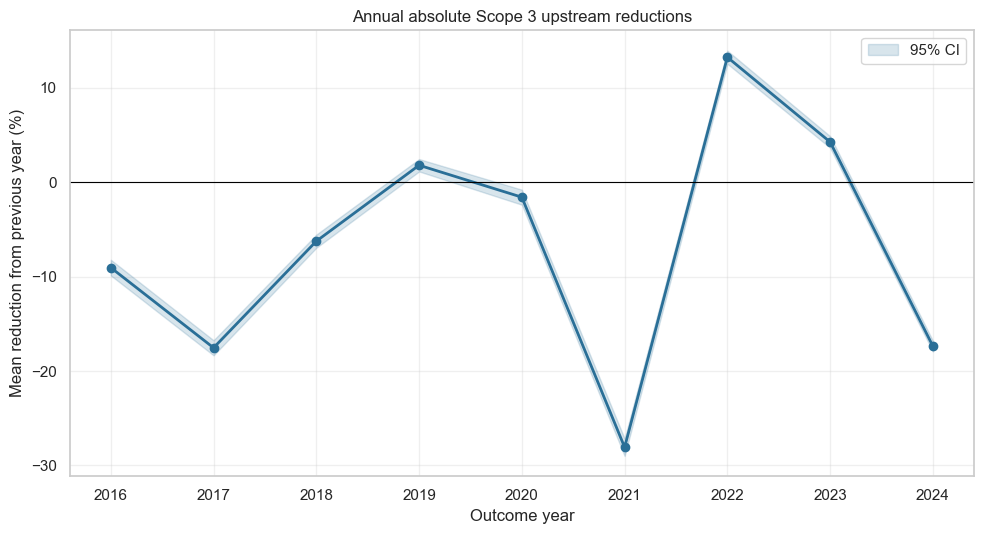

,year,mean,standard_error,observations,ci_low,ci_high
0,2016,-9.04,0.42,3270,-9.87,-8.21
1,2017,-17.53,0.41,4174,-18.33,-16.74
2,2018,-6.23,0.36,4968,-6.93,-5.54
3,2019,1.81,0.33,5657,1.15,2.46
4,2020,-1.58,0.41,6361,-2.37,-0.78
5,2021,-28.07,0.47,7132,-28.99,-27.15
6,2022,13.25,0.35,7702,12.56,13.95
7,2023,4.27,0.31,8453,3.66,4.89
8,2024,-17.36,0.29,9159,-17.92,-16.79


In [5]:
# Yearly Scope 3 reduction trend with 95% normal-approximation confidence intervals.
yearly = (analysis_panel.dropna(subset=['scope3_upstream_absolute_pct_reduction'])
    .groupby('year')['scope3_upstream_absolute_pct_reduction']
    .agg(mean='mean', standard_error='sem', observations='size')
    .reset_index())
yearly['ci_low'] = yearly['mean'] - 1.96 * yearly['standard_error']
yearly['ci_high'] = yearly['mean'] + 1.96 * yearly['standard_error']

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='white')
ax.set_facecolor('white')
ax.plot(yearly['year'], yearly['mean'], marker='o', color='#2a6f97', linewidth=2)
ax.fill_between(yearly['year'], yearly['ci_low'], yearly['ci_high'], color='#2a6f97', alpha=0.18, label='95% CI')
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='Annual absolute Scope 3 upstream reductions', xlabel='Outcome year',
       ylabel='Mean reduction from previous year (%)')
ax.set_xticks(ANALYSIS_YEARS)
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'scope3_upstream_absolute_reduction_by_year.pdf', bbox_inches='tight', facecolor='white')
plt.show()
display(yearly.round(2))

## Univariate associations

Spearman correlations are descriptive only. They show whether companies with higher supplier characteristics, or larger annual supplier changes, tend to have larger or smaller Scope 3 reductions; they do not establish a causal effect.

,outcome,predictor,observations,rho,p_value
0,Scope 3 upstream absolute emissions,lseg_revenue,58110,0.763,0.0
1,Scope 3 upstream absolute emissions,number_of_employees,47643,0.743,0.0
16,Scope 3 upstream absolute emissions,supplier_scope12_emissions_sum,21999,0.508,0.0
12,Scope 3 upstream absolute emissions,supplier_trucost_scope_1_emissions_sum,21999,0.505,0.0
3,Scope 3 upstream absolute emissions,number_of_supplier_sectors,30961,0.502,0.0
4,Scope 3 upstream absolute emissions,number_of_supplier_industries,30961,0.494,0.0
13,Scope 3 upstream absolute emissions,supplier_trucost_scope_2_emissions_sum,21999,0.477,0.0
2,Scope 3 upstream absolute emissions,number_of_tier_1_suppliers,30961,0.467,0.0
7,Scope 3 upstream absolute emissions,dominant_supplier_industry_pct,30961,-0.444,0.0
6,Scope 3 upstream absolute emissions,dominant_supplier_sector_pct,30961,-0.431,0.0


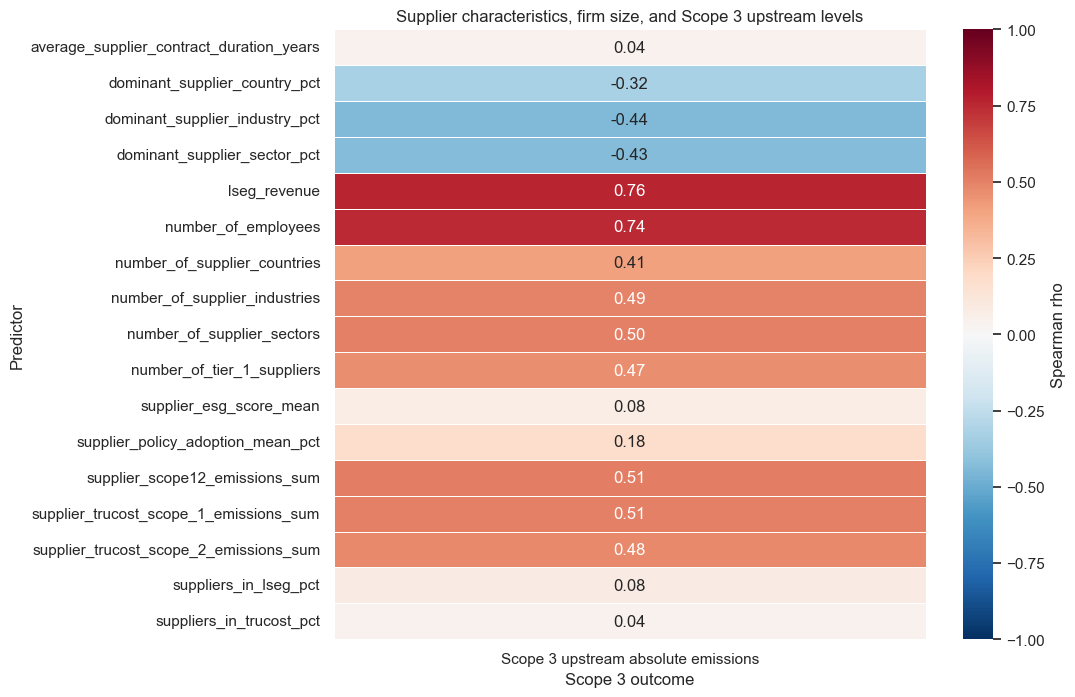

In [18]:
# These are level associations: neither outcome is an annual reduction.
SPEARMAN_PREDICTORS = [
    'lseg_revenue', 'number_of_employees', *SUPPLIER_CORE_FIELDS, *CHANGE_FIELDS,
    'supplier_policy_adoption_mean_pct', 'supplier_scope12_emissions_sum',
]
SPEARMAN_PREDICTORS = [column for column in dict.fromkeys(SPEARMAN_PREDICTORS) if column in level_analysis_panel.columns]
SPEARMAN_OUTCOMES = {
    'Scope 3 upstream absolute emissions': 'scope3_upstream_emissions',
   # 'Scope 3 upstream emissions intensity (emissions / Trucost revenue)': 'scope3_upstream_emissions_intensity',
}

def spearman_summary(frame, outcome, predictor):
    pairs = frame[[outcome, predictor]].apply(pd.to_numeric, errors='coerce').dropna()
    if len(pairs) < 3 or pairs.iloc[:, 0].nunique() < 2 or pairs.iloc[:, 1].nunique() < 2:
        return {'observations': len(pairs), 'rho': np.nan, 'p_value': np.nan}
    result = spearmanr(pairs.iloc[:, 0], pairs.iloc[:, 1])
    return {'observations': len(pairs), 'rho': result.statistic, 'p_value': result.pvalue}

correlation_rows = []
for outcome_label, outcome_column in SPEARMAN_OUTCOMES.items():
    for predictor in SPEARMAN_PREDICTORS:
        correlation_rows.append({
            'outcome': outcome_label,
            'predictor': predictor,
            **spearman_summary(level_analysis_panel, outcome_column, predictor),
        })
supplier_correlations = pd.DataFrame(correlation_rows)
supplier_correlations['absolute_rho'] = supplier_correlations['rho'].abs()
supplier_correlations = supplier_correlations.sort_values(['outcome', 'absolute_rho'], ascending=[True, False]).drop(columns='absolute_rho')
display(supplier_correlations.round(3))
supplier_correlations.to_csv(OUTPUT_DIR / 'supplier_scope3_level_spearman_correlations.csv', index=False)

rho_matrix = supplier_correlations.pivot(index='predictor', columns='outcome', values='rho')
fig, ax = plt.subplots(figsize=(11, max(5, 0.42 * len(rho_matrix))), facecolor='white')
sns.heatmap(rho_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Spearman rho'}, ax=ax)
ax.set(title='Supplier characteristics, firm size, and Scope 3 upstream levels', xlabel='Scope 3 outcome', ylabel='Predictor')
ax.tick_params(axis='x') # labelrotation=20
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'supplier_scope3_level_spearman_heatmap.pdf', bbox_inches='tight', facecolor='white')
plt.show()

## Firm fixed-effects model

This model uses the log level of absolute Scope 3 upstream emissions as its dependent variable. It estimates within-company associations with focal-firm revenue, employees, and supplier-base characteristics, includes outcome-year fixed effects, and clusters standard errors by focal company. It is associational, not causal.

In [7]:
# The dependent variable is the level of absolute Scope 3 upstream emissions,
# expressed in logs. Revenue and employees are focal-firm size controls.
model_panel = level_analysis_panel.copy()
for source_column, transformed_column in {
    'lseg_revenue': 'log_lseg_revenue',
    'number_of_employees': 'log_number_of_employees',
    'number_of_tier_1_suppliers': 'log_number_of_tier_1_suppliers',
    'supplier_scope12_emissions_sum': 'log_supplier_scope12_emissions_sum',
}.items():
    if source_column in model_panel.columns:
        model_panel[transformed_column] = np.log1p(pd.to_numeric(model_panel[source_column], errors='coerce').clip(lower=0))

LEVEL_FE_PREDICTORS = [
    'log_lseg_revenue', 'log_number_of_employees', 'number_of_supplier_sectors',
    'number_of_supplier_industries', 'number_of_supplier_countries',
    'dominant_supplier_sector_pct', 'dominant_supplier_industry_pct',
    'dominant_supplier_country_pct',
    'log_number_of_tier_1_suppliers', 'supplier_esg_score_mean',
    'supplier_policy_adoption_mean_pct', 'log_supplier_scope12_emissions_sum',
]
LEVEL_FE_PREDICTORS = [column for column in LEVEL_FE_PREDICTORS if column in model_panel.columns]

def fit_supplier_scope3_level_fe(frame, predictors):
    if not HAS_STATSMODELS:
        print('statsmodels is unavailable; the firm-FE model was skipped.')
        return None, pd.DataFrame(), pd.DataFrame()
    needed = [COMPANY_ID, 'year', 'scope3_upstream_emissions', *predictors]
    model_data = frame[needed].copy()
    model_data['log_scope3_upstream_emissions'] = np.log(
        pd.to_numeric(model_data['scope3_upstream_emissions'], errors='coerce')
    )
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()
    if len(model_data) < 30 or model_data[COMPANY_ID].nunique() < 10:
        print('Insufficient complete data for the firm-FE model.')
        return None, model_data, pd.DataFrame()

    # Standardization makes coefficients comparable: a one-SD predictor change.
    standardized_predictors = []
    for predictor in predictors:
        std = model_data[predictor].std()
        if pd.notna(std) and std > 0:
            standardized = f'z_{predictor}'
            model_data[standardized] = (model_data[predictor] - model_data[predictor].mean()) / std
            standardized_predictors.append(standardized)
    if not standardized_predictors:
        return None, model_data, pd.DataFrame()

    year_fe = pd.get_dummies(model_data['year'], prefix='year', drop_first=True, dtype=float)
    regressors = pd.concat([model_data[standardized_predictors], year_fe], axis=1).astype(float)
    groups = model_data[COMPANY_ID]
    y = model_data['log_scope3_upstream_emissions'] - model_data.groupby(COMPANY_ID)['log_scope3_upstream_emissions'].transform('mean')
    X = regressors - regressors.groupby(groups).transform('mean')
    X = X.loc[:, X.std().gt(1e-12)]
    retained_predictors = [column for column in standardized_predictors if column in X.columns]
    if not retained_predictors:
        print('No predictors have within-company variation.')
        return None, model_data, pd.DataFrame()
    result = sm.OLS(y, X, missing='drop').fit(cov_type='cluster', cov_kwds={'groups': groups, 'use_correction': True})
    table = pd.DataFrame({
        'coefficient_log_points_per_sd': result.params,
        'std_error': result.bse,
        'p_value': result.pvalues,
    })
    table['implied_pct_change_per_sd'] = 100 * (np.exp(table['coefficient_log_points_per_sd']) - 1)
    return result, model_data, table

fe_result, fe_data, supplier_fe_results = fit_supplier_scope3_level_fe(model_panel, LEVEL_FE_PREDICTORS)
if not supplier_fe_results.empty:
    display(supplier_fe_results.loc[[f'z_{column}' for column in LEVEL_FE_PREDICTORS if f'z_{column}' in supplier_fe_results.index]].round(4))
    supplier_fe_results.to_csv(OUTPUT_DIR / 'supplier_scope3_absolute_level_firm_fixed_effects.csv')
    print(f'Firm-FE level-model sample: {len(fe_data):,} rows; {fe_data[COMPANY_ID].nunique():,} companies.')

,coefficient_log_points_per_sd,std_error,p_value,implied_pct_change_per_sd
z_log_lseg_revenue,0.3837,0.0951,0.0001,46.7704
z_log_number_of_employees,0.1849,0.0526,0.0004,20.3153
z_number_of_supplier_sectors,-0.0463,0.0304,0.1283,-4.5205
z_number_of_supplier_industries,0.0723,0.0285,0.0113,7.4997
z_number_of_supplier_countries,0.0193,0.0314,0.5386,1.9494
z_dominant_supplier_sector_pct,-0.0292,0.0177,0.0988,-2.8736
z_dominant_supplier_industry_pct,0.0225,0.0187,0.2278,2.2785
z_dominant_supplier_country_pct,0.0051,0.0149,0.7308,0.5151
z_log_number_of_tier_1_suppliers,0.1227,0.0359,0.0006,13.0497
z_supplier_esg_score_mean,-0.0060,0.0126,0.6368,-0.5937


Firm-FE level-model sample: 12,107 rows; 2,513 companies.


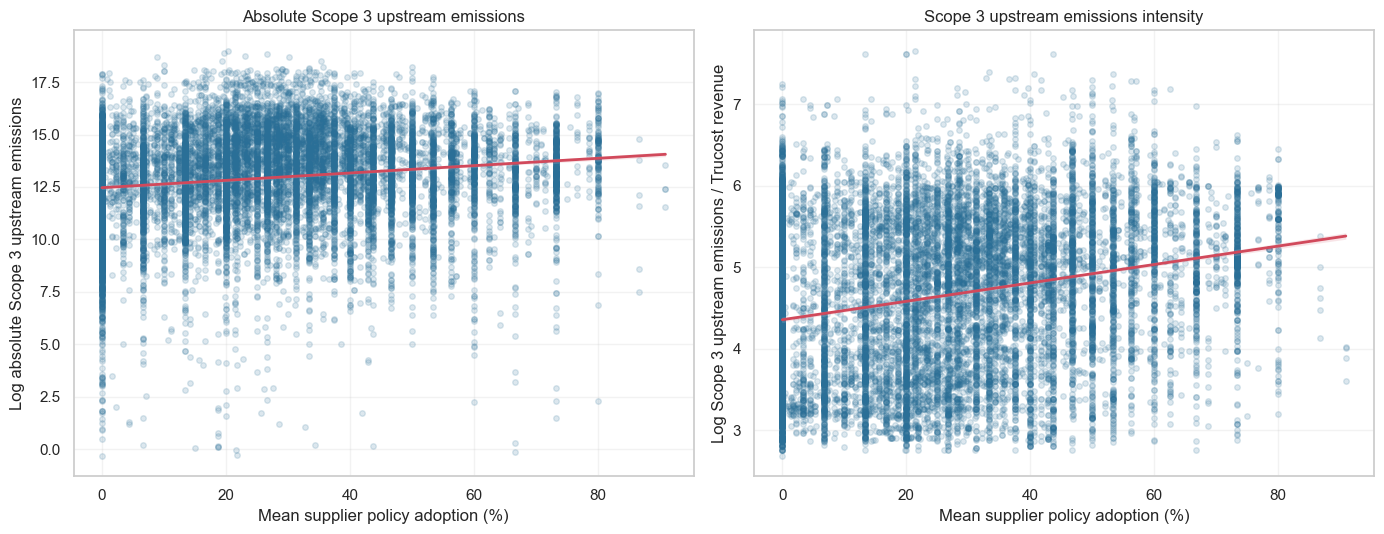

These plots are descriptive; use the firm-FE level model for adjusted within-company associations.


In [8]:
# Descriptive level plots: the left panel uses absolute emissions and the right
# panel uses revenue-normalized emissions intensity. Neither is a reduction.
plot_data = level_analysis_panel[[
    'supplier_policy_adoption_mean_pct', 'scope3_upstream_emissions',
    'scope3_upstream_emissions_intensity',
]].apply(pd.to_numeric, errors='coerce').dropna()
plot_data['log_scope3_upstream_emissions'] = np.log(plot_data['scope3_upstream_emissions'])
plot_data['log_scope3_upstream_emissions_intensity'] = np.log(plot_data['scope3_upstream_emissions_intensity'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')
for ax, outcome, title, ylabel in [
    (axes[0], 'log_scope3_upstream_emissions', 'Absolute Scope 3 upstream emissions', 'Log absolute Scope 3 upstream emissions'),
    (axes[1], 'log_scope3_upstream_emissions_intensity', 'Scope 3 upstream emissions intensity', 'Log Scope 3 upstream emissions / Trucost revenue'),
]:
    ax.set_facecolor('white')
    sns.regplot(
        data=plot_data, x='supplier_policy_adoption_mean_pct', y=outcome,
        scatter_kws={'alpha': 0.16, 's': 16, 'color': '#2a6f97'},
        line_kws={'color': '#d1495b', 'linewidth': 2}, ax=ax,
    )
    ax.set(title=title, xlabel='Mean supplier policy adoption (%)', ylabel=ylabel)
    ax.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'supplier_policy_scope3_absolute_and_intensity_levels.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('These plots are descriptive; use the firm-FE level model for adjusted within-company associations.')

## FactSet-only supplier-profile analysis

This section deliberately excludes supplier ESG, supplier policies, LSEG coverage, and Trucost supplier-emissions fields as predictors. It uses only the FactSet supplier-network profile: scale, diversity, concentration, relationship structure, and dominant supplier-type profiles. The outcomes remain focal-firm Scope 3 upstream absolute emissions and Scope 3 upstream intensity.

,supplier_profile_measure,category,coverage_pct,observations
0,number_of_tier_1_suppliers,Network scale,51.1,30993
10,average_supplier_contract_duration_years,Relationship structure,47.5,28770
7,dominant_supplier_country_pct,Supplier concentration,51.1,30993
9,dominant_supplier_entity_type_pct,Supplier concentration,51.1,30993
6,dominant_supplier_industry_pct,Supplier concentration,51.1,30993
8,dominant_supplier_region_pct,Supplier concentration,51.1,30993
5,dominant_supplier_sector_pct,Supplier concentration,51.1,30993
3,number_of_supplier_countries,Supplier diversity,51.1,30993
2,number_of_supplier_industries,Supplier diversity,51.1,30993
4,number_of_supplier_regions,Supplier diversity,51.1,30993


,outcome,supplier_profile_category,supplier_profile_measure,observations,spearman_rho,p_value
0,Absolute Scope 3 upstream emissions,Network scale,number_of_tier_1_suppliers,30961,0.467,0.000
10,Absolute Scope 3 upstream emissions,Relationship structure,average_supplier_contract_duration_years,28745,0.042,0.000
6,Absolute Scope 3 upstream emissions,Supplier concentration,dominant_supplier_industry_pct,30961,-0.444,0.000
5,Absolute Scope 3 upstream emissions,Supplier concentration,dominant_supplier_sector_pct,30961,-0.431,0.000
7,Absolute Scope 3 upstream emissions,Supplier concentration,dominant_supplier_country_pct,30961,-0.321,0.000
8,Absolute Scope 3 upstream emissions,Supplier concentration,dominant_supplier_region_pct,30961,-0.259,0.000
9,Absolute Scope 3 upstream emissions,Supplier concentration,dominant_supplier_entity_type_pct,30961,-0.217,0.000
1,Absolute Scope 3 upstream emissions,Supplier diversity,number_of_supplier_sectors,30961,0.502,0.000
2,Absolute Scope 3 upstream emissions,Supplier diversity,number_of_supplier_industries,30961,0.494,0.000
3,Absolute Scope 3 upstream emissions,Supplier diversity,number_of_supplier_countries,30961,0.408,0.000


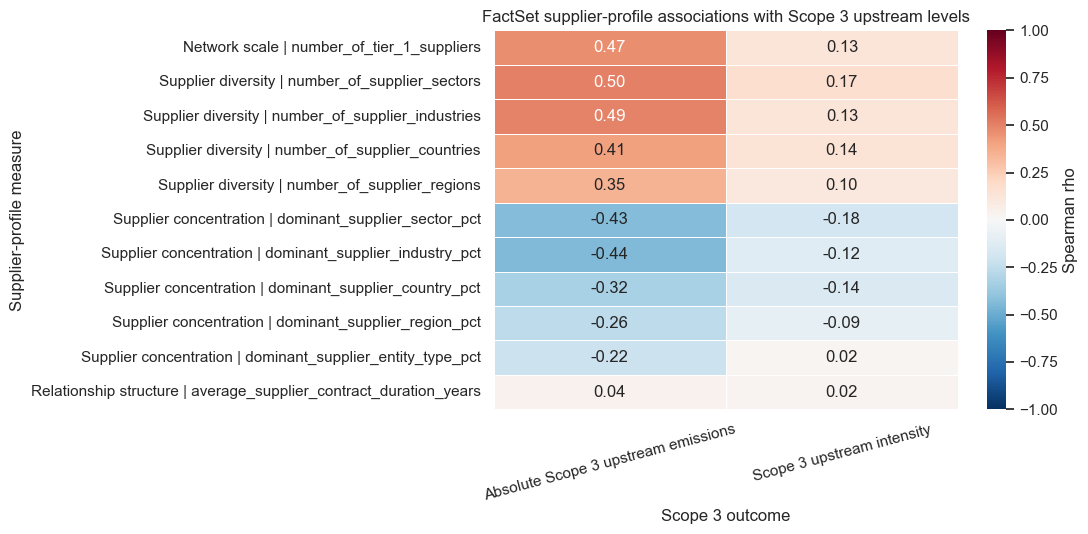

In [19]:
# FactSet-only numeric supplier-profile categories.
FACTSET_SUPPLIER_CATEGORIES = {
    'Network scale': ['number_of_tier_1_suppliers'],
    'Supplier diversity': [
        'number_of_supplier_sectors', 'number_of_supplier_industries',
        'number_of_supplier_countries', 'number_of_supplier_regions',
    ],
    'Supplier concentration': [
        'dominant_supplier_sector_pct', 'dominant_supplier_industry_pct',
        'dominant_supplier_country_pct', 'dominant_supplier_region_pct',
        'dominant_supplier_entity_type_pct',
    ],
    'Relationship structure': ['average_supplier_contract_duration_years'],
}
FACTSET_PROFILE_CATEGORICAL_FIELDS = [
    'dominant_supplier_sector', 'dominant_supplier_industry',
    'dominant_supplier_country', 'dominant_supplier_region',
    'dominant_supplier_entity_type',
]
FACTSET_PROFILE_CATEGORICAL_FIELDS = [
    field for field in FACTSET_PROFILE_CATEGORICAL_FIELDS if field in level_analysis_panel.columns
]
FACTSET_NUMERIC_PROFILE_FIELDS = [
    field for fields in FACTSET_SUPPLIER_CATEGORIES.values() for field in fields
    if field in level_analysis_panel.columns
]
FACTSET_FIELD_TO_CATEGORY = {
    field: category for category, fields in FACTSET_SUPPLIER_CATEGORIES.items()
    for field in fields if field in FACTSET_NUMERIC_PROFILE_FIELDS
}

factset_profile_panel = level_analysis_panel.copy()
for field in FACTSET_NUMERIC_PROFILE_FIELDS:
    factset_profile_panel[field] = pd.to_numeric(factset_profile_panel[field], errors='coerce')

factset_profile_coverage = pd.DataFrame({
    'category': pd.Series(FACTSET_FIELD_TO_CATEGORY),
    'coverage_pct': factset_profile_panel[FACTSET_NUMERIC_PROFILE_FIELDS].notna().mean().mul(100),
    'observations': factset_profile_panel[FACTSET_NUMERIC_PROFILE_FIELDS].notna().sum(),
}).rename_axis('supplier_profile_measure').reset_index()
display(factset_profile_coverage.sort_values(['category', 'supplier_profile_measure']).round(1))

FACTSET_PROFILE_OUTCOMES = {
    'Absolute Scope 3 upstream emissions': 'scope3_upstream_emissions',
    'Scope 3 upstream intensity': 'scope3_upstream_emissions_intensity',
}
factset_spearman_rows = []
for outcome_label, outcome in FACTSET_PROFILE_OUTCOMES.items():
    for field in FACTSET_NUMERIC_PROFILE_FIELDS:
        pairs = factset_profile_panel[[outcome, field]].apply(pd.to_numeric, errors='coerce').dropna()
        if len(pairs) < 3 or pairs[outcome].nunique() < 2 or pairs[field].nunique() < 2:
            rho, p_value = np.nan, np.nan
        else:
            test = spearmanr(pairs[outcome], pairs[field])
            rho, p_value = test.statistic, test.pvalue
        factset_spearman_rows.append({
            'outcome': outcome_label,
            'supplier_profile_category': FACTSET_FIELD_TO_CATEGORY[field],
            'supplier_profile_measure': field,
            'observations': len(pairs), 'spearman_rho': rho, 'p_value': p_value,
        })

factset_profile_spearman = pd.DataFrame(factset_spearman_rows)
factset_profile_spearman['absolute_rho'] = factset_profile_spearman['spearman_rho'].abs()
factset_profile_spearman = factset_profile_spearman.sort_values(
    ['outcome', 'supplier_profile_category', 'absolute_rho'],
    ascending=[True, True, False],
).drop(columns='absolute_rho')
display(factset_profile_spearman.round(3))
factset_profile_spearman.to_csv(OUTPUT_DIR / 'factset_only_supplier_profile_scope3_spearman.csv', index=False)

rho_matrix = factset_profile_spearman.pivot(
    index='supplier_profile_measure', columns='outcome', values='spearman_rho'
).reindex(FACTSET_NUMERIC_PROFILE_FIELDS)
rho_matrix.index = [f'{FACTSET_FIELD_TO_CATEGORY[field]} | {field}' for field in rho_matrix.index]
fig, ax = plt.subplots(figsize=(11, max(5.5, 0.45 * len(rho_matrix))), facecolor='white')
sns.heatmap(rho_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Spearman rho'}, ax=ax)
ax.set(title='FactSet supplier-profile associations with Scope 3 upstream levels', xlabel='Scope 3 outcome', ylabel='Supplier-profile measure')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'factset_only_supplier_profile_scope3_spearman_heatmap.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [10]:
# Dominant supplier profiles are categorical FactSet variables. Summarise them
# descriptively rather than imposing arbitrary numeric codes in the FE model.
MIN_PROFILE_GROUP_OBSERVATIONS = 30
profile_level_tables = {}
for profile_field in FACTSET_PROFILE_CATEGORICAL_FIELDS:
    profile_table = (factset_profile_panel.dropna(subset=[profile_field])
        .groupby(profile_field, as_index=False)
        .agg(
            company_years=(COMPANY_ID, 'size'),
            companies=(COMPANY_ID, 'nunique'),
            mean_scope3_absolute=('scope3_upstream_emissions', 'mean'),
            median_scope3_absolute=('scope3_upstream_emissions', 'median'),
            mean_scope3_intensity=('scope3_upstream_emissions_intensity', 'mean'),
            median_scope3_intensity=('scope3_upstream_emissions_intensity', 'median'),
        ))
    profile_table = profile_table.loc[profile_table['company_years'].ge(MIN_PROFILE_GROUP_OBSERVATIONS)]
    profile_level_tables[profile_field] = profile_table.sort_values('company_years', ascending=False)
    print(f'\n{profile_field}: groups with at least {MIN_PROFILE_GROUP_OBSERVATIONS} company-years')
    display(profile_level_tables[profile_field].head(15).round(3))
    profile_level_tables[profile_field].to_csv(
        OUTPUT_DIR / f'factset_only_{profile_field}_scope3_levels.csv', index=False
    )


dominant_supplier_sector: groups with at least 30 company-years


,dominant_supplier_sector,company_years,companies,mean_scope3_absolute,median_scope3_absolute,mean_scope3_intensity,median_scope3_intensity
5,Distribution Services,4160,1215,1400151.349,434297.484,220.084,187.402
8,Finance,3069,826,792253.585,167950.634,56.424,26.524
10,Health Technology,2883,764,624008.125,59809.222,104.095,80.745
17,Technology Services,2358,770,872167.613,97071.473,56.049,38.924
16,Retail Trade,2223,640,3046578.269,481575.227,168.388,130.938
6,Electronic Technology,2167,664,1178756.834,388117.082,157.123,142.629
3,Consumer Non-Durables,1783,511,3130434.739,937384.067,303.119,220.633
4,Consumer Services,1563,503,670642.111,171482.266,99.703,54.778
13,Non-Energy Minerals,1432,424,2363378.631,491896.076,238.171,184.171
14,Process Industries,1351,442,4961485.136,1064249.855,280.489,264.787



dominant_supplier_industry: groups with at least 30 company-years


,dominant_supplier_industry,company_years,companies,mean_scope3_absolute,median_scope3_absolute,mean_scope3_intensity,median_scope3_intensity
100,Pharmaceuticals: Major,1762,466,757891.855,70472.636,95.916,75.000
127,Wholesale Distributors,1683,511,2564458.681,899464.922,273.545,248.052
40,Electronics Distributors,1601,438,835205.031,239268.748,153.705,149.475
64,Information Technology Services,1092,364,890812.034,115133.976,73.739,39.272
97,Packaged Software,1041,414,1338817.590,134154.685,55.866,41.033
35,Electric Utilities,1020,291,2356074.895,876919.263,188.622,169.181
117,Specialty Stores,842,252,6033086.560,693783.626,187.183,189.417
21,Chemicals: Specialty,676,236,5640476.027,1117299.211,273.008,262.451
114,Semiconductors,625,176,989922.367,306301.815,153.149,146.188
45,Finance/Rental/Leasing,602,228,668178.907,159502.214,93.992,26.469



dominant_supplier_country: groups with at least 30 company-years


,dominant_supplier_country,company_years,companies,mean_scope3_absolute,median_scope3_absolute,mean_scope3_intensity,median_scope3_intensity
88,United States,9891,2405,2110998.312,417313.199,147.824,93.553
16,China,3235,1080,2758851.549,483638.873,174.171,125.921
39,Japan,2735,724,1802414.158,390488.782,169.624,118.673
79,Taiwan,1462,484,1106619.694,344936.024,198.951,157.237
13,Canada,1415,452,779707.619,179718.972,129.415,86.446
74,South Korea,1340,404,2892847.599,532263.353,196.494,147.994
2,Australia,1220,433,822219.999,229830.518,168.514,104.284
33,India,1068,449,1751784.856,219109.288,174.749,103.313
87,United Kingdom,907,365,799083.195,154226.688,115.617,53.194
30,Hong Kong,738,276,994537.340,322874.882,164.288,95.123



dominant_supplier_region: groups with at least 30 company-years


,dominant_supplier_region,company_years,companies,mean_scope3_absolute,median_scope3_absolute,mean_scope3_intensity,median_scope3_intensity
1,Asia,14686,3642,2176190.525,427727.770,179.726,130.563
5,North America,9518,2487,1506686.358,309900.815,145.700,88.430
2,Europe,4632,1486,1134231.274,209213.404,132.838,77.494
6,Pacific,677,245,470894.863,113973.354,152.310,70.453
3,Latin America,639,201,1160697.886,374647.577,157.206,100.908
0,Africa,438,171,438911.360,212372.023,137.974,88.489
4,Middle East,403,177,2013219.820,176883.640,183.933,97.519



dominant_supplier_entity_type: groups with at least 30 company-years


,dominant_supplier_entity_type,company_years,companies,mean_scope3_absolute,median_scope3_absolute,mean_scope3_intensity,median_scope3_intensity
7,PUB,27152,5968,1888548.568,367695.662,164.490,110.945
10,SUB,1623,680,692471.818,141316.366,143.467,83.121
1,EXT,828,356,552085.442,170696.205,136.758,81.676
3,HOL,717,306,596710.562,174147.482,123.175,70.478
9,PVT,475,230,566430.025,160032.494,149.923,87.899
5,MUC,147,34,295847.467,30051.859,34.373,25.923


,predictor,coefficient_log_points_per_sd,std_error,p_value,implied_pct_change_per_sd,supplier_profile_measure,supplier_profile_category,outcome,observations,companies
0,z_log_number_of_tier_1_suppliers,0.1952,0.0323,0.0000,21.5500,number_of_tier_1_suppliers,Network scale,Absolute Scope 3 upstream emissions,28745,5978
10,z_average_supplier_contract_duration_years,-0.0023,0.0081,0.7743,-0.2332,average_supplier_contract_duration_years,Relationship structure,Absolute Scope 3 upstream emissions,28745,5978
7,z_dominant_supplier_country_pct,0.0116,0.0168,0.4900,1.1659,dominant_supplier_country_pct,Supplier concentration,Absolute Scope 3 upstream emissions,28745,5978
9,z_dominant_supplier_entity_type_pct,0.0018,0.0063,0.7765,0.1799,dominant_supplier_entity_type_pct,Supplier concentration,Absolute Scope 3 upstream emissions,28745,5978
6,z_dominant_supplier_industry_pct,0.0345,0.0176,0.0502,3.5063,dominant_supplier_industry_pct,Supplier concentration,Absolute Scope 3 upstream emissions,28745,5978
8,z_dominant_supplier_region_pct,-0.0005,0.0136,0.9735,-0.0451,dominant_supplier_region_pct,Supplier concentration,Absolute Scope 3 upstream emissions,28745,5978
5,z_dominant_supplier_sector_pct,-0.0235,0.0160,0.1412,-2.3270,dominant_supplier_sector_pct,Supplier concentration,Absolute Scope 3 upstream emissions,28745,5978
3,z_log_number_of_supplier_countries,-0.0101,0.0320,0.7517,-1.0089,number_of_supplier_countries,Supplier diversity,Absolute Scope 3 upstream emissions,28745,5978
2,z_log_number_of_supplier_industries,0.0052,0.0386,0.8931,0.5200,number_of_supplier_industries,Supplier diversity,Absolute Scope 3 upstream emissions,28745,5978
4,z_log_number_of_supplier_regions,0.0338,0.0206,0.1004,3.4415,number_of_supplier_regions,Supplier diversity,Absolute Scope 3 upstream emissions,28745,5978


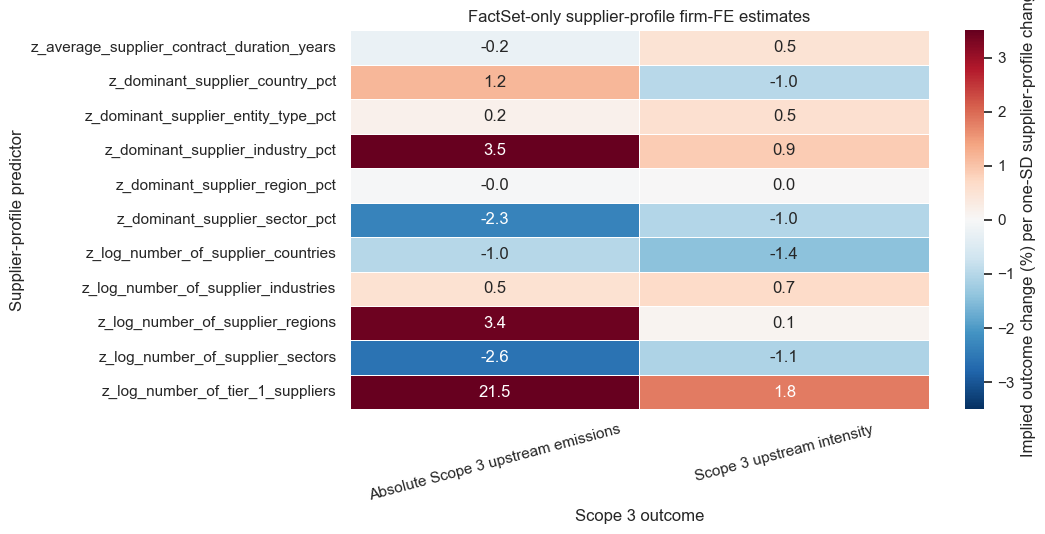

In [20]:
# Firm fixed-effects models with FactSet-only numeric supplier profiles.
# Estimate separate models for absolute Scope 3 upstream emissions and intensity.
factset_fe_panel = factset_profile_panel.copy()
FACTSET_FE_PREDICTORS = []
for field in FACTSET_NUMERIC_PROFILE_FIELDS:
    if field.startswith('number_of_'):
        transformed = f'log_{field}'
        factset_fe_panel[transformed] = np.log1p(factset_fe_panel[field].clip(lower=0))
    else:
        transformed = field
    FACTSET_FE_PREDICTORS.append(transformed)

def fit_factset_supplier_profile_fe(frame, outcome, predictors):
    if not HAS_STATSMODELS:
        return None, pd.DataFrame(), pd.DataFrame()
    needed = [COMPANY_ID, 'year', outcome, *predictors]
    model_data = frame[needed].apply(pd.to_numeric, errors='coerce', downcast=None)
    model_data[COMPANY_ID] = frame.loc[model_data.index, COMPANY_ID]
    model_data['log_outcome'] = np.log(model_data[outcome])
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()
    if len(model_data) < 30 or model_data[COMPANY_ID].nunique() < 10:
        return None, model_data, pd.DataFrame()

    z_predictors = []
    for predictor in predictors:
        std = model_data[predictor].std()
        if pd.notna(std) and std > 0:
            z_name = f'z_{predictor}'
            model_data[z_name] = (model_data[predictor] - model_data[predictor].mean()) / std
            z_predictors.append(z_name)
    year_fe = pd.get_dummies(model_data['year'], prefix='year', drop_first=True, dtype=float)
    X = pd.concat([model_data[z_predictors], year_fe], axis=1).astype(float)
    groups = model_data[COMPANY_ID]
    y = model_data['log_outcome'] - model_data.groupby(COMPANY_ID)['log_outcome'].transform('mean')
    X = X - X.groupby(groups).transform('mean')
    X = X.loc[:, X.std().gt(1e-12)]
    z_predictors = [predictor for predictor in z_predictors if predictor in X.columns]
    if not z_predictors:
        return None, model_data, pd.DataFrame()
    fitted = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups, 'use_correction': True})
    results = pd.DataFrame({
        'coefficient_log_points_per_sd': fitted.params[z_predictors],
        'std_error': fitted.bse[z_predictors],
        'p_value': fitted.pvalues[z_predictors],
    })
    results['implied_pct_change_per_sd'] = 100 * (np.exp(results['coefficient_log_points_per_sd']) - 1)
    return fitted, model_data, results

factset_fe_rows = []
for outcome_label, outcome in FACTSET_PROFILE_OUTCOMES.items():
    fitted, model_data, results = fit_factset_supplier_profile_fe(
        factset_fe_panel, outcome, FACTSET_FE_PREDICTORS
    )
    if results.empty:
        print(f'No estimable FactSet-only FE model for {outcome_label}.')
        continue
    results = results.reset_index(names='predictor')
    results['supplier_profile_measure'] = results['predictor'].str.removeprefix('z_log_').str.removeprefix('z_')
    results['supplier_profile_category'] = results['supplier_profile_measure'].map(FACTSET_FIELD_TO_CATEGORY)
    results['outcome'] = outcome_label
    results['observations'] = len(model_data)
    results['companies'] = model_data[COMPANY_ID].nunique()
    factset_fe_rows.append(results)

factset_profile_fe_results = pd.concat(factset_fe_rows, ignore_index=True) if factset_fe_rows else pd.DataFrame()
if not factset_profile_fe_results.empty:
    display(factset_profile_fe_results.sort_values(['outcome', 'supplier_profile_category', 'predictor']).round(4))
    factset_profile_fe_results.to_csv(OUTPUT_DIR / 'factset_only_supplier_profile_scope3_firm_fe.csv', index=False)

    effect_matrix = factset_profile_fe_results.pivot(
        index='predictor', columns='outcome', values='implied_pct_change_per_sd'
    )
    max_effect = max(float(effect_matrix.abs().stack().quantile(0.95)), 1) if not effect_matrix.empty else 1
    fig, ax = plt.subplots(figsize=(11, max(5.5, 0.5 * len(effect_matrix))), facecolor='white')
    sns.heatmap(effect_matrix, cmap='RdBu_r', center=0, vmin=-max_effect, vmax=max_effect,
                annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Implied outcome change (%) per one-SD supplier-profile change'}, ax=ax)
    ax.set(title='FactSet-only supplier-profile firm-FE estimates', xlabel='Scope 3 outcome', ylabel='Supplier-profile predictor')
    ax.tick_params(axis='x', labelrotation=15)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'factset_only_supplier_profile_scope3_firm_fe_heatmap.pdf', bbox_inches='tight', facecolor='white')
    plt.show()

## Extended FactSet-only model: supplier sector, region, and country controls

The model below adds the dominant supplier sector, region, and country as categorical variables. Countries represented by fewer than 100 company-years are pooled into Other / rare; the omitted category is the first retained category in each variable. Categorical effects are therefore relative to that reference category, whereas numeric supplier-profile effects remain one-standard-deviation changes.

,predictor,coefficient_log_points,std_error,p_value,predictor_type,supplier_profile_category,implied_pct_change,outcome,observations,companies
36,dominant_supplier_country_Belgium,0.0056,0.1018,0.9564,categorical,dominant_supplier_country,0.5582,Absolute Scope 3 upstream emissions,28745,5978
37,dominant_supplier_country_Bermuda,0.1119,0.1590,0.4815,categorical,dominant_supplier_country,11.8392,Absolute Scope 3 upstream emissions,28745,5978
38,dominant_supplier_country_Brazil,-0.0743,0.0481,0.1229,categorical,dominant_supplier_country,-7.1569,Absolute Scope 3 upstream emissions,28745,5978
39,dominant_supplier_country_Canada,0.0460,0.0437,0.2926,categorical,dominant_supplier_country,4.7120,Absolute Scope 3 upstream emissions,28745,5978
40,dominant_supplier_country_Chile,0.0259,0.0485,0.5933,categorical,dominant_supplier_country,2.6241,Absolute Scope 3 upstream emissions,28745,5978
...,...,...,...,...,...,...,...,...,...,...
72,z_dominant_supplier_sector_pct,-0.0096,0.0066,0.1460,numeric (one SD),Supplier concentration,-0.9576,Scope 3 upstream intensity,28745,5978
70,z_log_number_of_supplier_countries,-0.0166,0.0140,0.2386,numeric (one SD),Supplier diversity,-1.6419,Scope 3 upstream intensity,28745,5978
69,z_log_number_of_supplier_industries,0.0059,0.0142,0.6804,numeric (one SD),Supplier diversity,0.5873,Scope 3 upstream intensity,28745,5978
71,z_log_number_of_supplier_regions,0.0038,0.0079,0.6241,numeric (one SD),Supplier diversity,0.3855,Scope 3 upstream intensity,28745,5978


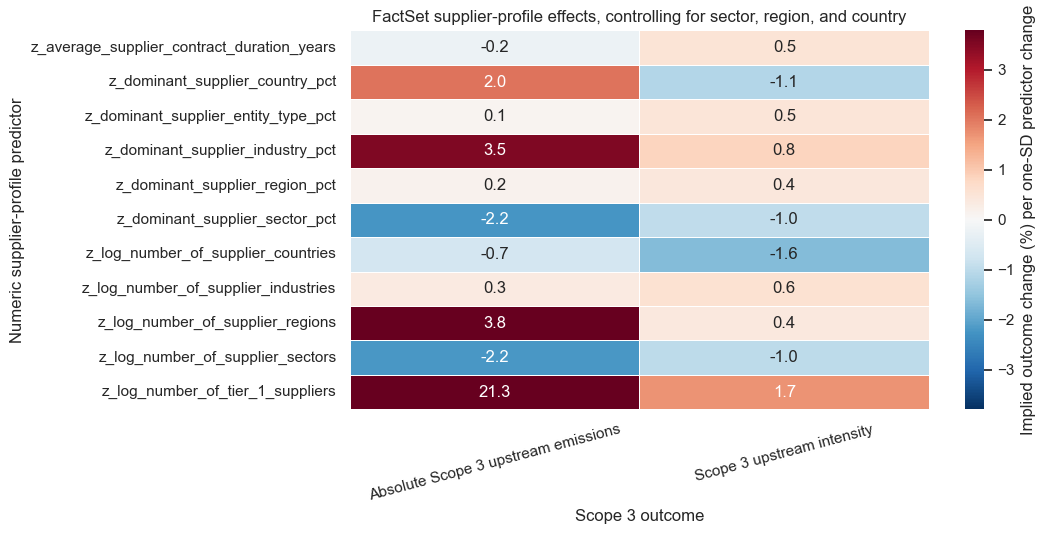

Categorical coefficients are relative to each field﷿﷿﷿﷿﷿﷿﷿﷿﷿s omitted reference category.


,predictor,coefficient_log_points,std_error,p_value,predictor_type,supplier_profile_category,implied_pct_change,outcome,observations,companies
57,dominant_supplier_country_Singapore,-0.1519,0.0615,0.0135,categorical,dominant_supplier_country,-14.0930,Absolute Scope 3 upstream emissions,28745,5978
51,dominant_supplier_country_Malaysia,-0.1652,0.0809,0.0410,categorical,dominant_supplier_country,-15.2301,Absolute Scope 3 upstream emissions,28745,5978
46,dominant_supplier_country_Indonesia,-0.1396,0.0716,0.0513,categorical,dominant_supplier_country,-13.0272,Absolute Scope 3 upstream emissions,28745,5978
50,dominant_supplier_country_Japan,-0.0660,0.0403,0.1016,categorical,dominant_supplier_country,-6.3883,Absolute Scope 3 upstream emissions,28745,5978
38,dominant_supplier_country_Brazil,-0.0743,0.0481,0.1229,categorical,dominant_supplier_country,-7.1569,Absolute Scope 3 upstream emissions,28745,5978
...,...,...,...,...,...,...,...,...,...,...
80,dominant_supplier_sector_Consumer Non-Durables,0.0039,0.0151,0.7988,categorical,dominant_supplier_sector,0.3864,Scope 3 upstream intensity,28745,5978
96,dominant_supplier_sector_Utilities,-0.0026,0.0228,0.9092,categorical,dominant_supplier_sector,-0.2599,Scope 3 upstream intensity,28745,5978
91,dominant_supplier_sector_Process Industries,-0.0020,0.0188,0.9168,categorical,dominant_supplier_sector,-0.1960,Scope 3 upstream intensity,28745,5978
84,dominant_supplier_sector_Energy Minerals,0.0022,0.0245,0.9293,categorical,dominant_supplier_sector,0.2176,Scope 3 upstream intensity,28745,5978


In [21]:
FACTSET_CATEGORICAL_FE_FIELDS = [
    field for field in [
        'dominant_supplier_sector', 'dominant_supplier_region',
        'dominant_supplier_country',
    ] if field in factset_fe_panel.columns
]
MIN_CATEGORY_OBSERVATIONS = 100

def fit_factset_supplier_profile_fe_with_categories(frame, outcome, numeric_predictors, categorical_fields):
    if not HAS_STATSMODELS:
        return None, pd.DataFrame(), pd.DataFrame()
    needed = [COMPANY_ID, 'year', outcome, *numeric_predictors, *categorical_fields]
    model_data = frame[needed].copy()
    for field in [outcome, *numeric_predictors]:
        model_data[field] = pd.to_numeric(model_data[field], errors='coerce')
    model_data['log_outcome'] = np.log(model_data[outcome])
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[outcome, *numeric_predictors])

    category_dummies = []
    category_term_map = {}
    for field in categorical_fields:
        values = model_data[field].astype('string').str.strip().fillna('Unreported')
        frequent = values.value_counts().loc[lambda counts: counts.ge(MIN_CATEGORY_OBSERVATIONS)].index
        grouped_values = values.where(values.isin(frequent), 'Other / rare')
        dummies = pd.get_dummies(grouped_values, prefix=field, drop_first=True, dtype=float)
        category_dummies.append(dummies)
        category_term_map.update({term: field for term in dummies.columns})

    z_predictors = []
    for predictor in numeric_predictors:
        std = model_data[predictor].std()
        if pd.notna(std) and std > 0:
            z_name = f'z_{predictor}'
            model_data[z_name] = (model_data[predictor] - model_data[predictor].mean()) / std
            z_predictors.append(z_name)
    if not z_predictors:
        return None, model_data, pd.DataFrame()

    year_fe = pd.get_dummies(model_data['year'], prefix='year', drop_first=True, dtype=float)
    X = pd.concat([model_data[z_predictors], *category_dummies, year_fe], axis=1).astype(float)
    groups = model_data[COMPANY_ID]
    y = model_data['log_outcome'] - model_data.groupby(COMPANY_ID)['log_outcome'].transform('mean')
    X = X - X.groupby(groups).transform('mean')
    X = X.loc[:, X.std().gt(1e-12)]
    retained_terms = [term for term in [*z_predictors, *category_term_map] if term in X.columns]
    if not retained_terms or model_data[COMPANY_ID].nunique() < 10:
        return None, model_data, pd.DataFrame()
    fitted = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups, 'use_correction': True})
    results = pd.DataFrame({
        'coefficient_log_points': fitted.params[retained_terms],
        'std_error': fitted.bse[retained_terms],
        'p_value': fitted.pvalues[retained_terms],
    }).reset_index(names='predictor')
    results['predictor_type'] = np.where(results['predictor'].str.startswith('z_'), 'numeric (one SD)', 'categorical')
    results['supplier_profile_category'] = results['predictor'].map(category_term_map)
    results.loc[results['predictor_type'].eq('numeric (one SD)'), 'supplier_profile_category'] = (
        results.loc[results['predictor_type'].eq('numeric (one SD)'), 'predictor']
        .str.removeprefix('z_log_').str.removeprefix('z_').map(FACTSET_FIELD_TO_CATEGORY)
    )
    results['implied_pct_change'] = 100 * (np.exp(results['coefficient_log_points']) - 1)
    return fitted, model_data, results

factset_extended_fe_rows = []
for outcome_label, outcome in FACTSET_PROFILE_OUTCOMES.items():
    fitted, model_data, results = fit_factset_supplier_profile_fe_with_categories(
        factset_fe_panel, outcome, FACTSET_FE_PREDICTORS, FACTSET_CATEGORICAL_FE_FIELDS
    )
    if results.empty:
        print(f'No estimable extended FactSet-only model for {outcome_label}.')
        continue
    results['outcome'] = outcome_label
    results['observations'] = len(model_data)
    results['companies'] = model_data[COMPANY_ID].nunique()
    factset_extended_fe_rows.append(results)

factset_extended_fe_results = pd.concat(factset_extended_fe_rows, ignore_index=True) if factset_extended_fe_rows else pd.DataFrame()
if not factset_extended_fe_results.empty:
    display(factset_extended_fe_results.sort_values(['outcome', 'predictor_type', 'supplier_profile_category', 'predictor']).round(4))
    factset_extended_fe_results.to_csv(
        OUTPUT_DIR / 'factset_only_supplier_profile_scope3_firm_fe_with_sector_region_country.csv',
        index=False,
    )

    numeric_effects = factset_extended_fe_results.loc[
        factset_extended_fe_results['predictor_type'].eq('numeric (one SD)')
    ].pivot(index='predictor', columns='outcome', values='implied_pct_change')
    if not numeric_effects.empty:
        maximum = max(float(numeric_effects.abs().stack().quantile(0.95)), 1)
        fig, ax = plt.subplots(figsize=(11, max(5, 0.5 * len(numeric_effects))), facecolor='white')
        sns.heatmap(numeric_effects, cmap='RdBu_r', center=0, vmin=-maximum, vmax=maximum,
                    annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                    cbar_kws={'label': 'Implied outcome change (%) per one-SD predictor change'}, ax=ax)
        ax.set(title='FactSet supplier-profile effects, controlling for sector, region, and country',
               xlabel='Scope 3 outcome', ylabel='Numeric supplier-profile predictor')
        ax.tick_params(axis='x', labelrotation=15)
        plt.tight_layout()
        fig.savefig(OUTPUT_DIR / 'factset_supplier_profile_fe_controls_sector_region_country.pdf', bbox_inches='tight', facecolor='white')
        plt.show()

    categorical_effects = factset_extended_fe_results.loc[
        factset_extended_fe_results['predictor_type'].eq('categorical')
    ].sort_values(['outcome', 'supplier_profile_category', 'p_value'])
    print('Categorical coefficients are relative to each field﷿﷿﷿﷿﷿﷿﷿﷿﷿s omitted reference category.')
    display(categorical_effects.round(4))

## Supplier-specific variables: census, composition, coverage, and policy adoption

This section reports the supplier variables independently of the focal-firm Scope 3 models. FactSet defines the Tier-1 network and supplier sector, industry, country, region, entity type, and relationship characteristics. LSEG supplies supplier ESG scores and policy indicators through the FactSet-to-ISIN link. Trucost supplies supplier Scope 1 and Scope 2 emissions through the matched panel. No CDP dataset or CDP-derived field is read.

Composition percentages below use one observation per unique supplier so that a supplier serving several focal firms is not counted repeatedly. Time-varying ESG, policy, and emissions summaries use one observation per supplier-year. Policy adoption is shown both among suppliers for which LSEG reports the policy field and relative to the full supplier-year universe; the distinction prevents sparse LSEG coverage from being interpreted as non-adoption.

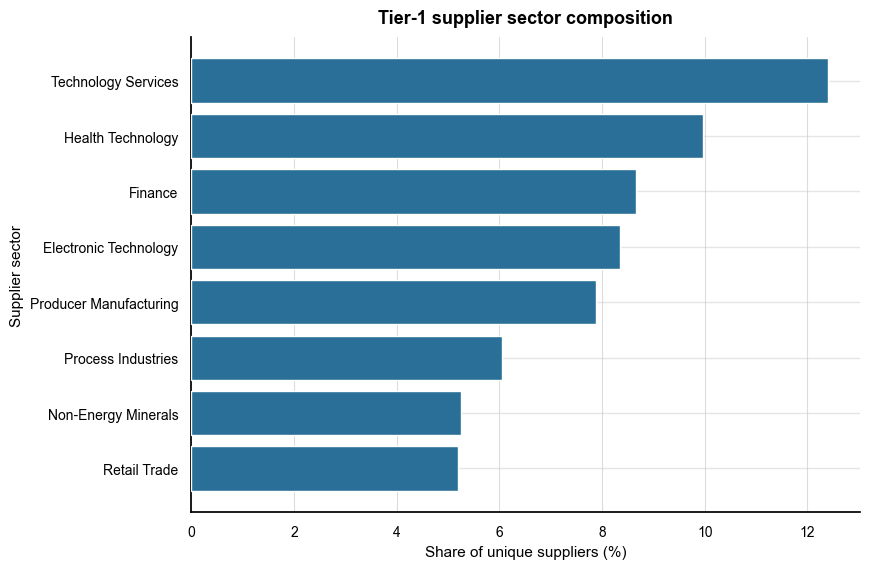

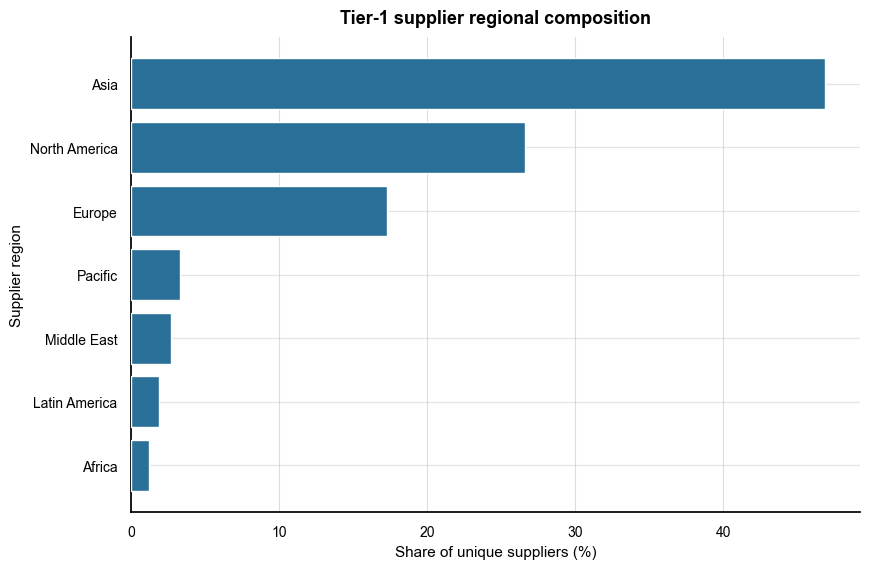

In [13]:
SUPPLIER_DETAIL_PATH = PROJECT_ROOT / 'data/processed/supplier_factset_lseg/company_year_supplier_detail.csv.gz'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'dataset_readers'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
if not SUPPLIER_DETAIL_PATH.exists():
    raise FileNotFoundError(f'Supplier detail not found: {SUPPLIER_DETAIL_PATH}')

detail = pd.read_csv(SUPPLIER_DETAIL_PATH, compression='gzip', low_memory=False)
detail = detail.rename(columns={'company_id': FACTSET_COMPANY_ID})
detail['year'] = pd.to_numeric(detail['year'], errors='coerce').astype('Int64')
detail[FACTSET_COMPANY_ID] = detail[FACTSET_COMPANY_ID].astype('string').str.strip()
detail['supplier_id'] = detail['supplier_id'].astype('string').str.strip()
detail = detail.loc[detail['supplier_id'].notna() & detail['year'].isin(PANEL_YEARS)].copy()
supplier_year = detail.sort_values(['supplier_id', 'year']).drop_duplicates(['supplier_id', 'year'])

def supplier_attribute_snapshot(frame, column):
    ranked = frame[['supplier_id', column]].copy()
    ranked['_reported'] = ranked[column].notna() & ranked[column].astype('string').str.strip().ne('')
    return (ranked.sort_values(['supplier_id', '_reported'], ascending=[True, False])
            .drop_duplicates('supplier_id').drop(columns='_reported'))

def boolean_flag(values):
    normalized = values.astype('string').str.strip().str.casefold()
    return normalized.isin(['true', '1', 'yes', 'y'])

coverage_by_supplier = detail.groupby('supplier_id').agg(
    ever_in_lseg=('supplier_in_lseg', lambda x: boolean_flag(x).any()),
    ever_in_trucost=('supplier_in_trucost', lambda x: boolean_flag(x).any()),
).reset_index()

supplier_census = pd.DataFrame({
    'measure': [
        'Notebook-07 focal companies', 'Notebook-07 focal-company years',
        'Supplier-covered focal-company years', 'Tier-1 relationships',
        'Unique Tier-1 suppliers', 'Mean suppliers per focal-company year',
        'Median suppliers per focal-company year', 'Suppliers ever matched to LSEG',
        'Suppliers ever matched to Trucost',
    ],
    'value': [
        panel.loc[base_sample_mask, COMPANY_ID].nunique(), int(base_sample_mask.sum()),
        panel.loc[base_sample_mask, 'number_of_tier_1_suppliers'].notna().sum(), len(detail),
        detail['supplier_id'].nunique(), panel.loc[base_sample_mask, 'number_of_tier_1_suppliers'].mean(),
        panel.loc[base_sample_mask, 'number_of_tier_1_suppliers'].median(),
        coverage_by_supplier['ever_in_lseg'].sum(), coverage_by_supplier['ever_in_trucost'].sum(),
    ],
})

company_year_variables = [
    'number_of_tier_1_suppliers', 'number_of_supplier_sectors',
    'number_of_supplier_industries', 'number_of_supplier_countries',
    'number_of_supplier_regions', 'dominant_supplier_sector_pct',
    'dominant_supplier_industry_pct', 'dominant_supplier_country_pct',
    'dominant_supplier_region_pct', 'suppliers_in_lseg_pct',
    'suppliers_in_trucost_pct', 'supplier_esg_score_mean',
    'supplier_esg_score_median', 'average_supplier_contract_duration_years',
]
company_year_variables = [column for column in company_year_variables if column in supplier.columns]
supplier_variable_summary = supplier[company_year_variables].apply(pd.to_numeric, errors='coerce').describe(
    percentiles=[0.25, 0.5, 0.75]
).T.reset_index(names='variable').rename(columns={'50%': 'median'})

composition_tables = {}
for column, label in [
    ('supplier_sector', 'sector'), ('supplier_region', 'region'),
    ('supplier_country_name', 'country'), ('supplier_industry', 'industry'),
]:
    snapshot = supplier_attribute_snapshot(detail, column)
    snapshot[column] = snapshot[column].fillna('Not Classified')
    counts = snapshot[column].value_counts(dropna=False)
    table = pd.DataFrame({label: counts.index, 'supplier_count': counts.values})
    table['supplier_pct'] = 100 * table['supplier_count'] / table['supplier_count'].sum()
    composition_tables[label] = table
    table.to_csv(OUTPUT_DIR / f'overall_unique_supplier_{label}_composition.csv', index=False)

POLICY_LABELS = {
    'policy_emissions': 'Emissions policy',
    'policy_energy_efficiency': 'Energy-efficiency policy',
    'policy_environmental_supply_chain': 'Environmental supply-chain policy',
    'policy_sustainable_packaging': 'Sustainable-packaging policy',
    'policy_clean_energy': 'Clean-energy products',
    'take_back_recycling': 'Take-back and recycling',
    'hybrid_vehicles': 'Hybrid vehicles',
    'eco_design': 'Eco-design products',
    'sustainability_reporting': 'Sustainability reporting',
    'target_energy_efficiency': 'Energy-efficiency target',
    'transition_plan_offsets': 'Transition-plan offsets',
    'internal_carbon_policy': 'Internal carbon pricing',
    'environmental_supply_chain_monitoring': 'Environmental supply-chain monitoring',
    'environmental_supply_chain_management': 'Environmental supply-chain management',
    'environmental_materials_sourcing': 'Environmental materials sourcing',
    'iso_14000_or_ems': 'ISO 14000 or EMS',
}
policy_rows = []
for column, label in POLICY_LABELS.items():
    values = pd.to_numeric(supplier_year[column], errors='coerce')
    observed = values.notna()
    policy_rows.append({
        'policy': label,
        'supplier_years_observed': int(observed.sum()),
        'observation_coverage_pct': 100 * observed.mean(),
        'adoption_pct_among_observed': 100 * values.loc[observed].mean() if observed.any() else np.nan,
        'adoption_pct_of_all_supplier_years': 100 * values.eq(1).sum() / len(values),
    })
policy_adoption = pd.DataFrame(policy_rows).sort_values('adoption_pct_among_observed', ascending=False)

emission_rows = []
for column, label in [
    ('supplier_trucost_scope_1_emissions', 'Supplier Scope 1 emissions'),
    ('supplier_trucost_scope_2_emissions', 'Supplier Scope 2 emissions'),
]:
    values = pd.to_numeric(supplier_year[column], errors='coerce')
    observed = values.dropna()
    emission_rows.append({
        'measure': label, 'supplier_years_observed': len(observed),
        'coverage_pct': 100 * values.notna().mean(), 'mean': observed.mean(),
        'median': observed.median(), 'p25': observed.quantile(0.25),
        'p75': observed.quantile(0.75), 'p90': observed.quantile(0.90),
    })
emissions_distribution = pd.DataFrame(emission_rows)

supplier_census.to_csv(OUTPUT_DIR / 'supplier_census.csv', index=False)
supplier_variable_summary.to_csv(OUTPUT_DIR / 'supplier_variable_descriptive_statistics.csv', index=False)
policy_adoption.to_csv(OUTPUT_DIR / 'supplier_policy_adoption_overall.csv', index=False)
emissions_distribution.to_csv(OUTPUT_DIR / 'supplier_emissions_distribution.csv', index=False)

# display(supplier_census.round(2))
# display(supplier_variable_summary.round(2))
# display(composition_tables['sector'].head(15).round(2))
# display(composition_tables['region'].round(2))
# display(policy_adoption.round(2))
# display(emissions_distribution.round(2))

plots = [
    (
        composition_tables["sector"],
        "sector",
        "Tier-1 supplier sector composition",
        "supplier_sector_composition.pdf",
        8,
    ),
    (
        composition_tables["region"],
        "region",
        "Tier-1 supplier regional composition",
        "supplier_region_composition.pdf",
        8,
    ),
]

for table, category, title, filename, limit in plots:
    plotted = table.head(limit).sort_values("supplier_pct").reset_index(drop=True)
    y_positions = np.arange(len(plotted))

    fig, ax = plt.subplots(figsize=(9, 6), facecolor="white")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.barh(y_positions, plotted["supplier_pct"], color="#2a6f97", zorder=3)
    ax.set_yticks(y_positions, labels=plotted[category].astype(str), color="black")
    ax.set_title(title, color="black", fontsize=13, fontweight="semibold", pad=10)
    ax.set_xlabel("Share of unique suppliers (%)", color="black", fontsize=11)
    ax.set_ylabel("Supplier sector" if category == "sector" else "Supplier region", color="black", fontsize=11)
    ax.tick_params(axis="both", colors="black", labelsize=10)
    ax.set_xlim(left=0)

    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#d9d9d9", linewidth=0.8, alpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    plt.tight_layout(pad=1.5)
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.show()

In [14]:
BS = chr(92)
NL = chr(10)
n_suppliers = int(detail['supplier_id'].nunique())
n_relationships = len(detail)
n_company_years = int(base_sample_mask.sum())
supplier_covered_base = panel.loc[base_sample_mask, 'number_of_tier_1_suppliers'].notna()
supplier_covered_base_n = int(supplier_covered_base.sum())
supplier_covered_base_pct = 100 * supplier_covered_base.mean()
mean_suppliers = panel.loc[base_sample_mask, 'number_of_tier_1_suppliers'].mean()
median_suppliers = panel.loc[base_sample_mask, 'number_of_tier_1_suppliers'].median()
lseg_n = int(coverage_by_supplier['ever_in_lseg'].sum())
lseg_pct = 100 * coverage_by_supplier['ever_in_lseg'].mean()
trucost_n = int(coverage_by_supplier['ever_in_trucost'].sum())
trucost_pct = 100 * coverage_by_supplier['ever_in_trucost'].mean()
esg_values = pd.to_numeric(supplier_year['supplier_esg_score'], errors='coerce').dropna()
top_sectors = composition_tables['sector'].head(3)
top_regions = composition_tables['region'].head(3)
broad_policies = policy_adoption.loc[policy_adoption['observation_coverage_pct'].ge(10)].head(4)
scope1 = emissions_distribution.loc[emissions_distribution['measure'].eq('Supplier Scope 1 emissions')].iloc[0]
scope2 = emissions_distribution.loc[emissions_distribution['measure'].eq('Supplier Scope 2 emissions')].iloc[0]
sector_text = ', '.join(f'{row.sector} ({row.supplier_pct:.1f}{BS}%)' for row in top_sectors.itertuples())
region_text = ', '.join(f'{row.region} ({row.supplier_pct:.1f}{BS}%)' for row in top_regions.itertuples())
policy_text = ', '.join(
    f'{row.policy.lower()} ({row.adoption_pct_among_observed:.1f}{BS}%)'
    for row in broad_policies.itertuples()
)

latex_lines = [
    BS + 'subsection{Supplier-specific variables}',
    BS + 'label{sec:supplier_variables}',
    '',
    "We construct supplier-specific variables from FactSet's Tier-1 supply-chain relationships and enrich the identified suppliers with LSEG ESG and policy information and Trucost operational emissions. The unit used in the focal-firm analysis is the firm--year. For focal firm $i$ in year $t$, supplier breadth is $N_{it}=|" + BS + 'mathcal{S}_{it}|$, where $' + BS + 'mathcal{S}_{it}$ is the set of unique active Tier-1 suppliers. For category $k$ (sector, industry, country, or region), the count-based composition is',
    BS + 'begin{equation}',
    ' Share_{itk} = 100' + BS + 'times' + BS + 'frac{|' + BS + '{s' + BS + 'in' + BS + 'mathcal{S}_{it}:g(s)=k' + BS + '}|}{N_{it}}.',
    BS + 'end{equation}',
    "The dominant-category share is $" + BS + "max_k Share_{itk}$ and captures concentration in the largest supplier category. Count-based shares are the primary composition measures because FactSet's relationship revenue percentage is a relationship-importance proxy rather than audited procurement expenditure.",
    '',
    f'The resulting panel contains {n_relationships:,} active buyer--supplier--year relationships, {n_company_years:,} focal-firm years, and {n_suppliers:,} unique Tier-1 suppliers. A focal firm has {mean_suppliers:.2f} suppliers on average and {median_suppliers:.0f} at the median, indicating a strongly right-skewed supplier-network-size distribution. Among unique suppliers, {lseg_n:,} ({lseg_pct:.1f}{BS}%) are observed in LSEG in at least one year and {trucost_n:,} ({trucost_pct:.1f}{BS}%) are observed in Trucost in at least one year. Supplier ESG scores are available for {len(esg_values):,} supplier-years; their mean is {esg_values.mean():.2f} and their median is {esg_values.median():.2f}. These coverage rates imply that ESG, policy, and emissions variables describe a selected, more observable subset of the full FactSet supplier network and should not be interpreted as universal supplier attributes.',
    '',
    f'The largest supplier sectors are {sector_text}. Geographically, {region_text} account for the largest shares of unique suppliers. These distributions characterize the extensive margin of the supplier network: every unique supplier receives equal weight. Relationship-revenue-weighted composition is retained as a supplementary measure, but it is not labelled procurement-spend composition.',
    '',
    f'LSEG policy indicators are retained separately rather than collapsed into a single index. Among policies with at least 10{BS}% supplier-year observation coverage, the highest adoption rates among observed suppliers are {policy_text}. Adoption percentages conditional on observation are reported alongside observation coverage and adoption as a share of all supplier-years. This distinction is important because a missing LSEG policy value is not coded as non-adoption.',
    '',
    f'Supplier emissions are highly right-skewed. For Scope~1, the supplier-year mean is {scope1["mean"]:,.0f}, whereas the median is {scope1["median"]:,.0f}; for Scope~2, the corresponding mean and median are {scope2["mean"]:,.0f} and {scope2["median"]:,.0f}. Accordingly, the empirical models use $' + BS + 'log(1+x)$ transformations for supplier-emissions aggregates, while the descriptive tables report the mean, median, interquartile range, 90th percentile, and coverage. The supplier variables are interpreted as network characteristics associated with focal-firm Scope~3 outcomes; the analysis does not assign a causal interpretation to these associations.',
    '',
    BS + 'paragraph{Variable interpretation.} Supplier count measures network breadth; numbers of sectors, industries, countries, and regions measure supplier-base diversity; dominant-category shares measure concentration; the mean and median supplier ESG scores summarize observed LSEG performance; policy variables measure policy-specific adoption among observed suppliers; and aggregated supplier Scope~1 and Scope~2 emissions proxy the operational carbon scale of the observed Trucost-covered supplier base. All coverage denominators and missing-value rules are reported explicitly.',
]
latex_analysis = NL.join(latex_lines) + NL
latex_path = REPORT_DIR / 'msom_supplier_specific_analysis.tex'
latex_path.write_text(latex_analysis, encoding='utf-8')
print(f'LaTeX analysis written to: {latex_path}')
print(latex_analysis)

LaTeX analysis written to: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\reports\msom_supplier_specific_analysis.tex
\subsection{Supplier-specific variables}
\label{sec:supplier_variables}

We construct supplier-specific variables from FactSet's Tier-1 supply-chain relationships and enrich the identified suppliers with LSEG ESG and policy information and Trucost operational emissions. The unit used in the focal-firm analysis is the firm--year. For focal firm $i$ in year $t$, supplier breadth is $N_{it}=|\mathcal{S}_{it}|$, where $\mathcal{S}_{it}$ is the set of unique active Tier-1 suppliers. For category $k$ (sector, industry, country, or region), the count-based composition is
\begin{equation}
 Share_{itk} = 100\times\frac{|\{s\in\mathcal{S}_{it}:g(s)=k\}|}{N_{it}}.
\end{equation}
The dominant-category share is $\max_k Share_{itk}$ and captures concentration in the largest supplier category. Count-based shares are the primary composition measures because FactSet's relation

In [15]:
def latex_escape(value):
    text = str(value)
    replacements = {
        '&': BS + '&', '%': BS + '%', '$': BS + '$', '#': BS + '#',
        '_': BS + '_', '{': BS + '{', '}': BS + '}',
    }
    for source, replacement in replacements.items():
        text = text.replace(source, replacement)
    return text

def latex_table(caption, label, headers, rows, alignment):
    lines = [
        BS + 'begin{table}[!htbp]',
        BS + 'centering',
        BS + 'caption{' + caption + '}',
        BS + 'label{' + label + '}',
        BS + 'begin{tabular}{' + alignment + '}',
        BS + 'toprule',
        ' & '.join(headers) + ' ' + BS + BS,
        BS + 'midrule',
    ]
    lines.extend(' & '.join(map(str, row)) + ' ' + BS + BS for row in rows)
    lines.extend([BS + 'bottomrule', BS + 'end{tabular}', BS + 'end{table}', ''])
    return NL.join(lines)

sample_rows = [
    ('Notebook-07 focal companies', f'{panel.loc[base_sample_mask, COMPANY_ID].nunique():,}'),
    ('Notebook-07 focal-company years', f'{int(base_sample_mask.sum()):,}'),
    ('Supplier-covered focal-company years', f'{supplier_covered_base_n:,} ({supplier_covered_base_pct:.1f}{BS}%)'),
    ('Buyer--supplier--year relationships', f'{len(detail):,}'),
    ('Unique Tier-1 suppliers', f'{detail["supplier_id"].nunique():,}'),
    ('Mean suppliers per focal-company year', f'{supplier["number_of_tier_1_suppliers"].mean():.2f}'),
    ('Median suppliers per focal-company year', f'{supplier["number_of_tier_1_suppliers"].median():.0f}'),
    ('Suppliers ever observed in LSEG', f'{lseg_n:,} ({lseg_pct:.1f}{BS}%)'),
    ('Suppliers ever observed in Trucost', f'{trucost_n:,} ({trucost_pct:.1f}{BS}%)'),
    ('Supplier-years with an ESG score', f'{len(esg_values):,}'),
]
sample_table_latex = latex_table(
    'Supplier sample and data coverage', 'tab:supplier_sample',
    ['Measure', 'Value'], sample_rows, 'lr'
)

annual_sample_rows = [
    (str(year), f'{int(base_sample_counts.loc[year]):,}') for year in ANALYSIS_YEARS
] + [('Total', f'{int(base_sample_counts.sum()):,}')]
annual_sample_table_latex = latex_table(
    'Annual Observations in the Base Analysis Sample', 'tab:sample_count',
    ['Year', 'Company-year observations'], annual_sample_rows, '@{}lr@{}'
)

sector_region_rows = []
sector_top = composition_tables['sector'].head(10).reset_index(drop=True)
region_all = composition_tables['region'].head(10).reset_index(drop=True)
for index in range(max(len(sector_top), len(region_all))):
    sector = sector_top.iloc[index] if index < len(sector_top) else None
    region = region_all.iloc[index] if index < len(region_all) else None
    sector_region_rows.append((
        latex_escape(sector['sector']) if sector is not None else '',
        f'{sector["supplier_pct"]:.1f}' if sector is not None else '',
        latex_escape(region['region']) if region is not None else '',
        f'{region["supplier_pct"]:.1f}' if region is not None else '',
    ))
composition_table_latex = latex_table(
    'Composition of unique Tier-1 suppliers', 'tab:supplier_composition',
    ['Supplier sector', 'Share (' + BS + '%)', 'Supplier region', 'Share (' + BS + '%)'],
    sector_region_rows, 'lrlr'
)

policy_rows_latex = [
    (
        latex_escape(row.policy), f'{int(row.supplier_years_observed):,}',
        f'{row.observation_coverage_pct:.1f}',
        f'{row.adoption_pct_among_observed:.1f}',
        f'{row.adoption_pct_of_all_supplier_years:.1f}',
    )
    for row in policy_adoption.sort_values('adoption_pct_among_observed', ascending=False).itertuples()
]
policy_table_latex = latex_table(
    'Supplier policy adoption and LSEG coverage', 'tab:supplier_policy_adoption',
    ['Policy', 'Observed $N$', 'Coverage (' + BS + '%)', 'Adoption observed (' + BS + '%)',
     'Adoption all supplier-years (' + BS + '%)'],
    policy_rows_latex, 'lrrrr'
)
policy_table_latex = policy_table_latex.replace(
    BS + 'begin{tabular}{lrrrr}',
    BS + 'resizebox{' + BS + 'textwidth}{!}{%' + NL + BS + 'begin{tabular}{lrrrr}',
).replace(BS + 'end{tabular}', BS + 'end{tabular}%' + NL + '}')

emission_rows_latex = [
    (
        latex_escape(row.measure), f'{int(row.supplier_years_observed):,}',
        f'{row.coverage_pct:.1f}', f'{row.mean:,.0f}',
        f'{row.median:,.0f}', f'{row.p25:,.0f}', f'{row.p75:,.0f}', f'{row.p90:,.0f}',
    )
    for row in emissions_distribution.itertuples()
]
emissions_table_latex = latex_table(
    'Distribution of supplier operational emissions', 'tab:supplier_emissions',
    ['Measure', 'Observed $N$', 'Coverage (' + BS + '%)', 'Mean', 'Median', 'P25', 'P75', 'P90'],
    emission_rows_latex, 'lrrrrrrr'
)
emissions_table_latex = emissions_table_latex.replace(
    BS + 'begin{tabular}{lrrrrrrr}',
    BS + 'resizebox{' + BS + 'textwidth}{!}{%' + NL + BS + 'begin{tabular}{lrrrrrrr}',
).replace(BS + 'end{tabular}', BS + 'end{tabular}%' + NL + '}')

references_latex = NL.join([
    BS + 'paragraph{Tables and visual summary.}',
    'Table~' + BS + 'ref{tab:sample_count} reproduces Notebook 07' + "'" + 's annual base-sample counts. '
    'Table~' + BS + 'ref{tab:supplier_sample} reports the supplier sample and cross-dataset coverage. '
    'Table~' + BS + 'ref{tab:supplier_composition} summarizes the sectoral and regional composition of unique suppliers, '
    'which is visualized in Figure~' + BS + 'ref{fig:supplier_composition}. '
    'Table~' + BS + 'ref{tab:supplier_policy_adoption} reports each LSEG policy separately and distinguishes field coverage '
    'from adoption conditional on observation. Table~' + BS + 'ref{tab:supplier_emissions} documents the skewed distributions '
    'of supplier Scope~1 and Scope~2 emissions.',
    '',
])

figure_latex = NL.join([
    BS + 'begin{figure}[!htbp]',
    BS + 'centering',
    BS + 'includegraphics[width=0.95' + BS + 'linewidth]{data/outputs/dataset_readers/supplier_scope3_reductions/supplier_sector_region_composition.pdf}',
    BS + 'caption{Sectoral and regional composition of unique Tier-1 suppliers. Each supplier is counted once, irrespective of the number of focal firms it serves.}',
    BS + 'label{fig:supplier_composition}',
    BS + 'end{figure}',
    '',
])

latex_document = NL.join([
    latex_analysis.rstrip(), '', references_latex.rstrip(), '',
    annual_sample_table_latex.rstrip(), '', sample_table_latex.rstrip(), '',
    composition_table_latex.rstrip(), '',
    figure_latex.rstrip(), '', policy_table_latex.rstrip(), '',
    emissions_table_latex.rstrip(), '',
])
latex_path.write_text(latex_document, encoding='utf-8')
print(f'LaTeX tables and figure references written to: {latex_path}')
print('Required manuscript packages: booktabs and graphicx.')

LaTeX tables and figure references written to: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\reports\msom_supplier_specific_analysis.tex
Required manuscript packages: booktabs and graphicx.


## Focal-firm ESG and supplier decomposition

This section evaluates whether a focal firm's LSEG ESG score is associated with the breadth and sectoral composition of its FactSet Tier-1 supplier network. Supplier breadth is measured by the number of unique active Tier-1 suppliers. Sector composition is represented by the count-based shares of the ten largest supplier-sector categories in the overall supplier population; all remaining sectors form the implicit reference group.

The analysis reports Spearman correlations as descriptive evidence and a within-firm model with year fixed effects and focal-firm size controls. The fixed-effects estimates use changes within the same focal firm over time and cluster standard errors by focal firm. These relationships remain associational rather than causal.

,measure,predictor,observations,spearman_rho,p_value,coefficient_esg_points_per_sd,std_error,fe_p_value,fe_observations,companies
0,Number of Tier-1 suppliers,log_number_of_tier_1_suppliers,30993,0.3779,0.000,1.5947,0.2984,0.0000,25445,5168
1,Technology Services supplier share,supplier_sector_share_technology_services,30993,0.0883,0.000,-0.3698,0.1610,0.0217,25445,5168
2,Health Technology supplier share,supplier_sector_share_health_technology,30993,-0.0015,0.787,0.3067,0.3070,0.3177,25445,5168
3,Finance supplier share,supplier_sector_share_finance,30993,0.1692,0.000,0.0732,0.2105,0.7281,25445,5168
4,Electronic Technology supplier share,supplier_sector_share_electronic_technology,30993,0.1015,0.000,0.1092,0.1847,0.5545,25445,5168
5,Producer Manufacturing supplier share,supplier_sector_share_producer_manufacturing,30993,0.1746,0.000,0.1047,0.1510,0.4878,25445,5168
6,Process Industries supplier share,supplier_sector_share_process_industries,30993,0.1696,0.000,0.2452,0.1498,0.1017,25445,5168
7,Non-Energy Minerals supplier share,supplier_sector_share_non_energy_minerals,30993,0.1542,0.000,-0.0347,0.2089,0.8682,25445,5168
8,Retail Trade supplier share,supplier_sector_share_retail_trade,30993,0.1588,0.000,0.1797,0.1737,0.3009,25445,5168
9,Consumer Non-Durables supplier share,supplier_sector_share_consumer_non_durables,30993,0.1499,0.000,-0.0623,0.1765,0.7243,25445,5168


Firm-FE sample: 25,445 firm-years and 5,168 focal firms.


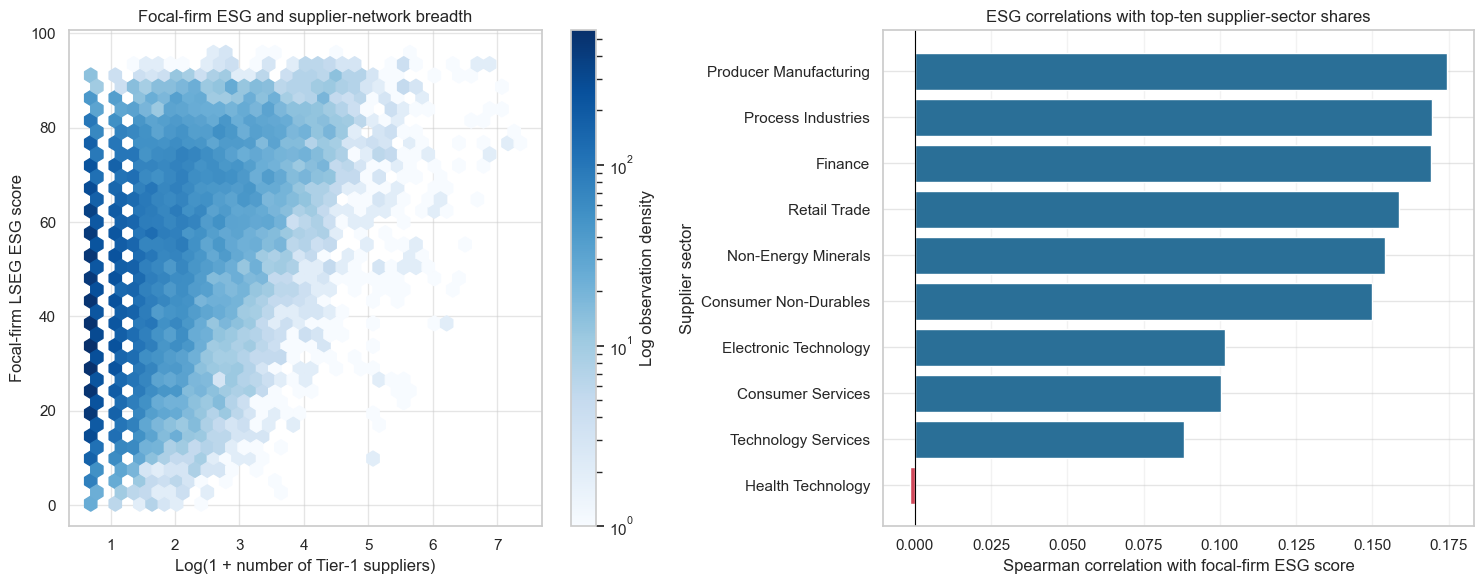

Updated LaTeX analysis: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\reports\msom_supplier_specific_analysis.tex


In [16]:
SECTOR_COMPOSITION_PATH = PROJECT_ROOT / 'data/processed/supplier_factset_lseg/company_year_supplier_sector_composition.csv'
if not SECTOR_COMPOSITION_PATH.exists():
    raise FileNotFoundError(f'Supplier-sector composition not found: {SECTOR_COMPOSITION_PATH}')

sector_composition = pd.read_csv(SECTOR_COMPOSITION_PATH, low_memory=False)
sector_composition = sector_composition.rename(columns={'company_id': FACTSET_COMPANY_ID})
sector_composition['year'] = pd.to_numeric(sector_composition['year'], errors='coerce').astype('Int64')
sector_composition[FACTSET_COMPANY_ID] = sector_composition[FACTSET_COMPANY_ID].astype('string').str.strip()
sector_composition['supplier_count_pct'] = pd.to_numeric(
    sector_composition['supplier_count_pct'], errors='coerce'
)

TOP_SECTOR_COUNT = 10
top_supplier_sectors = composition_tables['sector'].head(TOP_SECTOR_COUNT)['sector'].tolist()
sector_slug = {
    sector: 'supplier_sector_share_' + ''.join(
        character.lower() if character.isalnum() else '_'
        for character in sector
    ).strip('_')
    for sector in top_supplier_sectors
}
sector_subset = sector_composition.loc[
    sector_composition['supplier_sector'].isin(top_supplier_sectors),
    [FACTSET_COMPANY_ID, 'year', 'supplier_sector', 'supplier_count_pct'],
].copy()
sector_wide = sector_subset.pivot_table(
    index=[FACTSET_COMPANY_ID, 'year'], columns='supplier_sector',
    values='supplier_count_pct', aggfunc='sum', fill_value=0,
).reset_index().rename(columns=sector_slug)
sector_share_columns = [sector_slug[sector] for sector in top_supplier_sectors]

esg_supplier_panel = level_analysis_panel.merge(
    sector_wide, on=[FACTSET_COMPANY_ID, 'year'], how='left', validate='many_to_one'
)
supplier_coverage_mask = esg_supplier_panel['number_of_tier_1_suppliers'].notna()
esg_supplier_panel.loc[supplier_coverage_mask, sector_share_columns] = (
    esg_supplier_panel.loc[supplier_coverage_mask, sector_share_columns].fillna(0)
)
esg_supplier_panel['log_number_of_tier_1_suppliers'] = np.log1p(
    pd.to_numeric(esg_supplier_panel['number_of_tier_1_suppliers'], errors='coerce').clip(lower=0)
)
for source, target in [
    ('lseg_revenue', 'log_focal_revenue'),
    ('number_of_employees', 'log_focal_employees'),
]:
    if source in esg_supplier_panel.columns:
        esg_supplier_panel[target] = np.log1p(
            pd.to_numeric(esg_supplier_panel[source], errors='coerce').clip(lower=0)
        )

ESG_DECOMPOSITION_LABELS = {
    'log_number_of_tier_1_suppliers': 'Number of Tier-1 suppliers',
    **{sector_slug[sector]: f'{sector} supplier share' for sector in top_supplier_sectors},
}
ESG_DECOMPOSITION_PREDICTORS = list(ESG_DECOMPOSITION_LABELS)

esg_correlation_rows = []
for predictor in ESG_DECOMPOSITION_PREDICTORS:
    pairs = esg_supplier_panel[['esg_score', predictor]].apply(pd.to_numeric, errors='coerce').dropna()
    if len(pairs) >= 3 and pairs['esg_score'].nunique() > 1 and pairs[predictor].nunique() > 1:
        test = spearmanr(pairs['esg_score'], pairs[predictor])
        rho, p_value = test.statistic, test.pvalue
    else:
        rho, p_value = np.nan, np.nan
    esg_correlation_rows.append({
        'measure': ESG_DECOMPOSITION_LABELS[predictor], 'predictor': predictor,
        'observations': len(pairs), 'spearman_rho': rho, 'p_value': p_value,
    })
esg_supplier_correlations = pd.DataFrame(esg_correlation_rows)

ESG_SIZE_CONTROLS = [
    column for column in ['log_focal_revenue', 'log_focal_employees']
    if column in esg_supplier_panel.columns
]

def fit_focal_esg_supplier_fe(frame, predictors, controls):
    if not HAS_STATSMODELS:
        return None, pd.DataFrame(), pd.DataFrame()
    required = [COMPANY_ID, 'year', 'esg_score', *predictors, *controls]
    model_data = frame[required].copy()
    for column in ['year', 'esg_score', *predictors, *controls]:
        model_data[column] = pd.to_numeric(model_data[column], errors='coerce')
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()
    if len(model_data) < 30 or model_data[COMPANY_ID].nunique() < 10:
        return None, model_data, pd.DataFrame()

    standardized = []
    for predictor in [*predictors, *controls]:
        standard_deviation = model_data[predictor].std()
        if pd.notna(standard_deviation) and standard_deviation > 0:
            z_name = 'z_' + predictor
            model_data[z_name] = (
                model_data[predictor] - model_data[predictor].mean()
            ) / standard_deviation
            standardized.append(z_name)

    year_fixed_effects = pd.get_dummies(
        model_data['year'].astype(int), prefix='year', drop_first=True, dtype=float
    )
    regressors = pd.concat([model_data[standardized], year_fixed_effects], axis=1).astype(float)
    groups = model_data[COMPANY_ID]
    outcome = model_data['esg_score'] - model_data.groupby(COMPANY_ID)['esg_score'].transform('mean')
    regressors = regressors - regressors.groupby(groups).transform('mean')
    regressors = regressors.loc[:, regressors.std().gt(1e-12)]
    retained = ['z_' + predictor for predictor in predictors if 'z_' + predictor in regressors.columns]
    if not retained:
        return None, model_data, pd.DataFrame()

    fitted = sm.OLS(outcome, regressors).fit(
        cov_type='cluster', cov_kwds={'groups': groups, 'use_correction': True}
    )
    results = pd.DataFrame({
        'predictor': retained,
        'coefficient_esg_points_per_sd': fitted.params[retained].values,
        'std_error': fitted.bse[retained].values,
        'p_value': fitted.pvalues[retained].values,
    })
    results['predictor'] = results['predictor'].str.removeprefix('z_')
    results['measure'] = results['predictor'].map(ESG_DECOMPOSITION_LABELS)
    results['observations'] = len(model_data)
    results['companies'] = model_data[COMPANY_ID].nunique()
    return fitted, model_data, results

esg_fe_model, esg_fe_data, esg_supplier_fe = fit_focal_esg_supplier_fe(
    esg_supplier_panel, ESG_DECOMPOSITION_PREDICTORS, ESG_SIZE_CONTROLS
)

esg_relationship_results = esg_supplier_correlations.merge(
    esg_supplier_fe[[
        'measure', 'coefficient_esg_points_per_sd', 'std_error',
        'p_value', 'observations', 'companies',
    ]].rename(columns={
        'p_value': 'fe_p_value', 'observations': 'fe_observations',
    }),
    on='measure', how='left',
)
esg_relationship_results.to_csv(
    OUTPUT_DIR / 'focal_esg_supplier_decomposition_relationships.csv', index=False
)

display(esg_relationship_results.round(4))
if not esg_fe_data.empty:
    print(f'Firm-FE sample: {len(esg_fe_data):,} firm-years and {esg_fe_data[COMPANY_ID].nunique():,} focal firms.')

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')
hexbin_data = esg_supplier_panel[['log_number_of_tier_1_suppliers', 'esg_score']].dropna()
hexbin = axes[0].hexbin(
    hexbin_data['log_number_of_tier_1_suppliers'], hexbin_data['esg_score'],
    gridsize=35, mincnt=1, cmap='Blues', bins='log'
)
axes[0].set(
    title='Focal-firm ESG and supplier-network breadth',
    xlabel='Log(1 + number of Tier-1 suppliers)', ylabel='Focal-firm LSEG ESG score',
)
fig.colorbar(hexbin, ax=axes[0], label='Log observation density')

sector_plot = esg_supplier_correlations.loc[
    esg_supplier_correlations['predictor'].isin(sector_share_columns)
].copy().sort_values('spearman_rho')
sector_plot['sector'] = sector_plot['predictor'].map(
    {sector_slug[sector]: sector for sector in top_supplier_sectors}
)
colors = np.where(sector_plot['spearman_rho'].ge(0), '#2a6f97', '#d1495b')
axes[1].barh(sector_plot['sector'], sector_plot['spearman_rho'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set(
    title='ESG correlations with top-ten supplier-sector shares',
    xlabel='Spearman correlation with focal-firm ESG score', ylabel='Supplier sector',
)
axes[1].grid(axis='x', alpha=0.25)
plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / 'focal_esg_supplier_decomposition.pdf',
    bbox_inches='tight', facecolor='white',
)
plt.show()

count_row = esg_relationship_results.loc[
    esg_relationship_results['predictor'].eq('log_number_of_tier_1_suppliers')
].iloc[0]
sector_results = esg_relationship_results.loc[
    esg_relationship_results['predictor'].isin(sector_share_columns)
].copy()
strongest_positive = sector_results.loc[sector_results['spearman_rho'].idxmax()]
strongest_negative = sector_results.loc[sector_results['spearman_rho'].idxmin()]

esg_table_rows = []
for row in esg_relationship_results.itertuples():
    esg_table_rows.append((
        latex_escape(row.measure), f'{row.spearman_rho:.3f}',
        f'{row.p_value:.3f}', f'{row.coefficient_esg_points_per_sd:.3f}',
        f'{row.fe_p_value:.3f}',
    ))
esg_table_latex = latex_table(
    'Focal-firm ESG score and supplier decomposition',
    'tab:focal_esg_supplier_decomposition',
    ['Supplier-network measure', 'Spearman $' + BS + 'rho$', '$p$',
     'Firm-FE coefficient', '$p$'],
    esg_table_rows, 'lrrrr'
)
esg_table_latex = esg_table_latex.replace(
    BS + 'begin{tabular}{lrrrr}',
    BS + 'resizebox{' + BS + 'textwidth}{!}{%' + NL + BS + 'begin{tabular}{lrrrr}',
).replace(BS + 'end{tabular}', BS + 'end{tabular}%' + NL + '}')

esg_latex_section = NL.join([
    '% BEGIN FOCAL ESG SUPPLIER DECOMPOSITION',
    BS + 'subsection{Focal-firm ESG and supplier decomposition}',
    BS + 'label{sec:focal_esg_supplier_decomposition}',
    '',
    'We examine whether focal-firm ESG performance is associated with supplier-network breadth and the sectoral composition of Tier-1 suppliers. The ten sector categories are selected using their shares of the overall unique-supplier population; all other supplier sectors form the omitted residual composition. Table~' + BS + 'ref{tab:focal_esg_supplier_decomposition} reports both unadjusted Spearman correlations and within-firm estimates with year fixed effects, log focal-firm revenue, log employment, and focal-firm-clustered standard errors.',
    '',
    f'The number of Tier-1 suppliers has a Spearman correlation of {count_row.spearman_rho:.3f} with the focal-firm ESG score. In the firm fixed-effects specification, a one-standard-deviation increase in log supplier count is associated with {count_row.coefficient_esg_points_per_sd:.3f} ESG-score points ($p={count_row.fe_p_value:.3f}$). Across the top-ten sector shares, the largest positive descriptive association is for {strongest_positive.measure.lower()} ($' + BS + f'rho={strongest_positive.spearman_rho:.3f}$), while the largest negative association is for {strongest_negative.measure.lower()} ($' + BS + f'rho={strongest_negative.spearman_rho:.3f}$). Figure~' + BS + 'ref{fig:focal_esg_supplier_decomposition} visualizes supplier-network breadth and the sector-share correlations.',
    '',
    'The sector coefficients should be interpreted compositionally: increasing one sector share necessarily reduces the combined share of other sectors. The fixed-effects model identifies associations from within-firm changes over time and does not establish that changing supplier count or sector composition causes a change in ESG performance.',
    '',
    esg_table_latex.rstrip(),
    '',
    BS + 'begin{figure}[!htbp]',
    BS + 'centering',
    BS + 'includegraphics[width=' + BS + 'textwidth]{data/outputs/dataset_readers/supplier_scope3_reductions/focal_esg_supplier_decomposition.pdf}',
    BS + 'caption{Focal-firm ESG score and supplier decomposition. The left panel shows the joint distribution of ESG scores and supplier-network breadth. The right panel reports Spearman correlations between ESG scores and the shares of the ten largest supplier-sector categories.}',
    BS + 'label{fig:focal_esg_supplier_decomposition}',
    BS + 'end{figure}',
    '% END FOCAL ESG SUPPLIER DECOMPOSITION',
    '',
])

existing_latex = latex_path.read_text(encoding='utf-8')
marker = '% BEGIN FOCAL ESG SUPPLIER DECOMPOSITION'
if marker in existing_latex:
    existing_latex = existing_latex.split(marker, 1)[0].rstrip()
latex_path.write_text(existing_latex + NL + NL + esg_latex_section, encoding='utf-8')
print(f'Updated LaTeX analysis: {latex_path}')

## Lagged supplier decomposition, supplier risk, and Scope 3

This section studies whether prior supplier-network characteristics are associated with subsequent focal-firm Scope 3 upstream emissions and annual reductions. Supplier variables are lagged by one, two, and three calendar years. The core measures are supplier-network breadth, the percentage of emissions-covered suppliers classified as high emitters, supplier-sector diversification, and geographical concentration.

A high-emission supplier is defined as a supplier whose combined Trucost Scope 1 and Scope 2 emissions are in the top decile of the supplier-year distribution. Sector diversification is normalized Shannon entropy and ranges from zero (one sector) to one (evenly distributed across observed sectors). Geographical risk is represented by the regional Herfindahl concentration index; it captures concentration exposure rather than country-level political or regulatory risk. The ten largest supplier-sector shares are estimated in a separate composition model to avoid conflating the aggregate risk measures with detailed sector allocation.

All models include focal-firm fixed effects, outcome-year fixed effects, log revenue, log employment, and focal-firm-clustered standard errors. Scope 3 levels are modeled in logs. Reductions use the log change, $\log(E_{i,t-1})-\log(E_{it})$, so positive values indicate reductions. Results are associational.

,predictor,coefficient,std_error,p_value,observations,companies,measure,outcome,model,lag_years,interpretable_effect,effect_unit
0,log_number_of_tier_1_suppliers_lag1,0.0965,0.0197,0.0000,19190,3866,Supplier-network breadth,Scope 3 emissions level,Core supplier risk,1,10.1350,percent change in Scope 3 level per predictor SD
1,high_emission_supplier_pct_lag1,0.0042,0.0064,0.5052,19190,3866,High-emission suppliers (%),Scope 3 emissions level,Core supplier risk,1,0.4254,percent change in Scope 3 level per predictor SD
2,supplier_sector_diversification_lag1,0.0021,0.0072,0.7717,19190,3866,Supplier-sector diversification,Scope 3 emissions level,Core supplier risk,1,0.2078,percent change in Scope 3 level per predictor SD
3,supplier_geographic_concentration_hhi_lag1,-0.0070,0.0094,0.4579,19190,3866,Geographical concentration (HHI),Scope 3 emissions level,Core supplier risk,1,-0.6962,percent change in Scope 3 level per predictor SD
4,supplier_sector_share_technology_services_lag1,0.0029,0.0069,0.6716,27950,5227,Technology Services supplier share,Scope 3 emissions level,Top-ten sector composition,1,0.2920,percent change in Scope 3 level per predictor SD
...,...,...,...,...,...,...,...,...,...,...,...,...
79,supplier_sector_share_process_industries_lag3,-0.0024,0.0043,0.5837,19563,4333,Process Industries supplier share,Scope 3 annual reduction,Top-ten sector composition,3,-0.2370,log-reduction points x 100 per predictor SD
80,supplier_sector_share_non_energy_minerals_lag3,0.0010,0.0041,0.8018,19563,4333,Non-Energy Minerals supplier share,Scope 3 annual reduction,Top-ten sector composition,3,0.1037,log-reduction points x 100 per predictor SD
81,supplier_sector_share_retail_trade_lag3,-0.0012,0.0036,0.7350,19563,4333,Retail Trade supplier share,Scope 3 annual reduction,Top-ten sector composition,3,-0.1218,log-reduction points x 100 per predictor SD
82,supplier_sector_share_consumer_non_durables_lag3,-0.0037,0.0035,0.2957,19563,4333,Consumer Non-Durables supplier share,Scope 3 annual reduction,Top-ten sector composition,3,-0.3664,log-reduction points x 100 per predictor SD


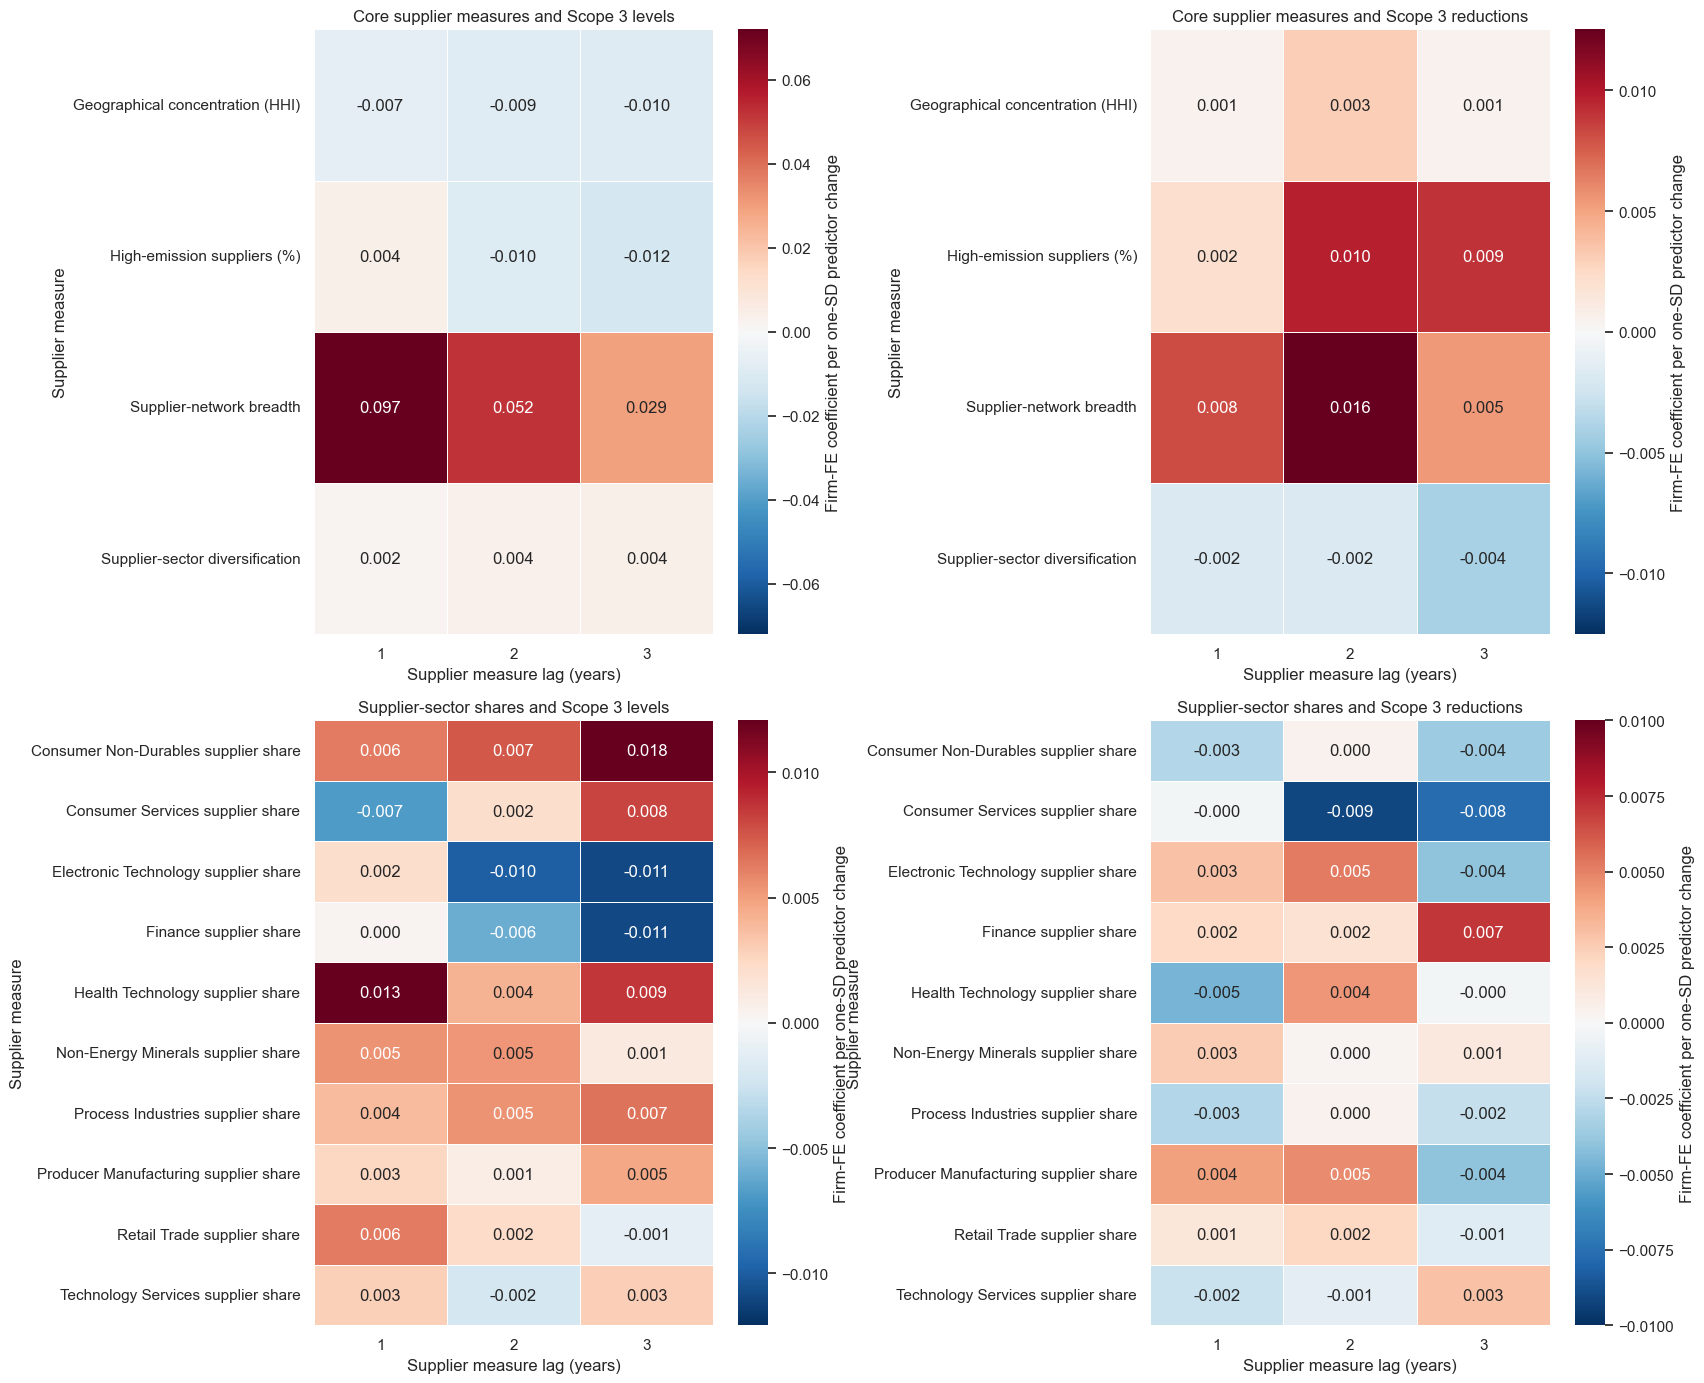

Updated lagged Scope 3 LaTeX analysis: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\reports\msom_supplier_specific_analysis.tex


In [17]:
REGION_COMPOSITION_PATH = PROJECT_ROOT / 'data/processed/supplier_factset_lseg/company_year_supplier_region_composition.csv'
if not REGION_COMPOSITION_PATH.exists():
    raise FileNotFoundError(f'Supplier-region composition not found: {REGION_COMPOSITION_PATH}')

# Classify high-emission suppliers within each year, using one observation per supplier-year.
emission_columns = [
    'supplier_trucost_scope_1_emissions',
    'supplier_trucost_scope_2_emissions',
]
supplier_year_emissions = (
    detail[['year', 'supplier_id', *emission_columns]]
    .assign(**{
        column: lambda frame, column=column: pd.to_numeric(frame[column], errors='coerce')
        for column in emission_columns
    })
    .groupby(['year', 'supplier_id'], as_index=False)[emission_columns]
    .median()
)
supplier_year_emissions['supplier_scope12_emissions'] = supplier_year_emissions[
    emission_columns
].sum(axis=1, min_count=1)
supplier_year_emissions['annual_scope12_p90'] = supplier_year_emissions.groupby('year')[
    'supplier_scope12_emissions'
].transform(lambda values: values.quantile(0.90))
supplier_year_emissions['high_emission_supplier'] = np.where(
    supplier_year_emissions['supplier_scope12_emissions'].notna(),
    supplier_year_emissions['supplier_scope12_emissions'].ge(
        supplier_year_emissions['annual_scope12_p90']
    ).astype(float),
    np.nan,
)

relationship_risk = detail[['year', FACTSET_COMPANY_ID, 'supplier_id']].merge(
    supplier_year_emissions[[
        'year', 'supplier_id', 'supplier_scope12_emissions', 'high_emission_supplier'
    ]],
    on=['year', 'supplier_id'], how='left', validate='many_to_one',
)
high_emission_exposure = relationship_risk.groupby(['year', FACTSET_COMPANY_ID], as_index=False).agg(
    number_of_tier_1_suppliers=('supplier_id', 'nunique'),
    emissions_covered_supplier_count=('supplier_scope12_emissions', 'count'),
    high_emission_supplier_count=('high_emission_supplier', 'sum'),
)
high_emission_exposure['high_emission_supplier_pct'] = 100 * (
    high_emission_exposure['high_emission_supplier_count']
    / high_emission_exposure['emissions_covered_supplier_count'].replace(0, np.nan)
)
high_emission_exposure['supplier_emissions_coverage_pct'] = 100 * (
    high_emission_exposure['emissions_covered_supplier_count']
    / high_emission_exposure['number_of_tier_1_suppliers']
)

def normalized_entropy_from_counts(group, category_column):
    classified = group.loc[
        group[category_column].notna()
        & group[category_column].astype('string').str.strip().ne('')
        & group[category_column].ne('Not Classified')
    ]
    counts = pd.to_numeric(classified['supplier_count'], errors='coerce').dropna()
    counts = counts.loc[counts.gt(0)]
    category_count = len(counts)
    if category_count == 0:
        return pd.Series({'entropy': np.nan, 'hhi': np.nan, 'classified_suppliers': 0})
    probabilities = counts / counts.sum()
    entropy = 0.0 if category_count == 1 else float(
        -(probabilities * np.log(probabilities)).sum() / np.log(category_count)
    )
    return pd.Series({
        'entropy': entropy,
        'hhi': float((probabilities ** 2).sum()),
        'classified_suppliers': float(counts.sum()),
    })

sector_diversification = (
    sector_composition.groupby(['year', FACTSET_COMPANY_ID])
    .apply(normalized_entropy_from_counts, category_column='supplier_sector', include_groups=False)
    .reset_index()
    .rename(columns={
        'entropy': 'supplier_sector_diversification',
        'hhi': 'supplier_sector_hhi',
        'classified_suppliers': 'sector_classified_supplier_count',
    })
)
region_composition = pd.read_csv(REGION_COMPOSITION_PATH, low_memory=False)
region_composition = region_composition.rename(columns={'company_id': FACTSET_COMPANY_ID})
region_composition['year'] = pd.to_numeric(region_composition['year'], errors='coerce').astype('Int64')
region_composition[FACTSET_COMPANY_ID] = region_composition[FACTSET_COMPANY_ID].astype('string').str.strip()
region_diversification = (
    region_composition.groupby(['year', FACTSET_COMPANY_ID])
    .apply(normalized_entropy_from_counts, category_column='supplier_region', include_groups=False)
    .reset_index()
    .rename(columns={
        'entropy': 'supplier_region_diversification',
        'hhi': 'supplier_geographic_concentration_hhi',
        'classified_suppliers': 'region_classified_supplier_count',
    })
)

supplier_risk_features = (
    high_emission_exposure
    .merge(sector_diversification, on=['year', FACTSET_COMPANY_ID], how='left', validate='one_to_one')
    .merge(region_diversification, on=['year', FACTSET_COMPANY_ID], how='left', validate='one_to_one')
    .merge(sector_wide, on=['year', FACTSET_COMPANY_ID], how='left', validate='one_to_one')
)
supplier_risk_features[sector_share_columns] = supplier_risk_features[sector_share_columns].fillna(0)
supplier_risk_features['log_number_of_tier_1_suppliers'] = np.log1p(
    supplier_risk_features['number_of_tier_1_suppliers'].clip(lower=0)
)

CORE_RISK_LABELS = {
    'log_number_of_tier_1_suppliers': 'Supplier-network breadth',
    'high_emission_supplier_pct': 'High-emission suppliers (%)',
    'supplier_sector_diversification': 'Supplier-sector diversification',
    'supplier_geographic_concentration_hhi': 'Geographical concentration (HHI)',
}
SECTOR_SCOPE3_LABELS = {
    sector_slug[sector]: f'{sector} supplier share'
    for sector in top_supplier_sectors
}
ALL_SCOPE3_FEATURES = [*CORE_RISK_LABELS, *SECTOR_SCOPE3_LABELS]

supplier_risk_features = firm[[COMPANY_ID, FACTSET_COMPANY_ID, 'year']].merge(
    supplier_risk_features, on=[FACTSET_COMPANY_ID, 'year'], how='left', validate='many_to_one'
)
supplier_risk_features = supplier_risk_features.sort_values([COMPANY_ID, 'year']).reset_index(drop=True)
for lag_years in (1, 2, 3):
    previous_year = supplier_risk_features.groupby(COMPANY_ID)['year'].shift(lag_years)
    contiguous = supplier_risk_features['year'].eq(previous_year + lag_years)
    for feature in ALL_SCOPE3_FEATURES:
        lagged = supplier_risk_features.groupby(COMPANY_ID)[feature].shift(lag_years)
        supplier_risk_features[f'{feature}_lag{lag_years}'] = lagged.where(contiguous)

scope3_lag_panel = panel.loc[panel['year'].isin(ANALYSIS_YEARS)].copy()
scope3_lag_panel = scope3_lag_panel.merge(
    supplier_risk_features[
        [COMPANY_ID, 'year']
        + [f'{feature}_lag{lag}' for lag in (1, 2, 3) for feature in ALL_SCOPE3_FEATURES]
        + ['supplier_emissions_coverage_pct']
    ],
    on=[COMPANY_ID, 'year'], how='left', validate='one_to_one',
)
scope3_lag_panel['log_scope3_upstream_emissions'] = np.log(
    pd.to_numeric(scope3_lag_panel['scope3_upstream_emissions'], errors='coerce').where(
        pd.to_numeric(scope3_lag_panel['scope3_upstream_emissions'], errors='coerce').gt(0)
    )
)
scope3_lag_panel['scope3_log_reduction'] = pd.to_numeric(
    scope3_lag_panel['scope3_upstream_absolute_log_reduction'], errors='coerce'
).where(~scope3_lag_panel['scope3_reduction_is_outlier'])
for source, target in [
    ('lseg_revenue', 'log_focal_revenue'),
    ('number_of_employees', 'log_focal_employees'),
]:
    if source in scope3_lag_panel.columns:
        scope3_lag_panel[target] = np.log1p(
            pd.to_numeric(scope3_lag_panel[source], errors='coerce').clip(lower=0)
        )
SCOPE3_MODEL_CONTROLS = [
    column for column in ['log_focal_revenue', 'log_focal_employees']
    if column in scope3_lag_panel.columns
]

SCOPE3_OUTCOMES = {
    'Scope 3 emissions level': 'log_scope3_upstream_emissions',
    'Scope 3 annual reduction': 'scope3_log_reduction',
}

def fit_lagged_supplier_scope3_fe(frame, outcome, predictors, controls):
    required = [COMPANY_ID, 'year', outcome, *predictors, *controls]
    model_data = frame[required].copy()
    for column in ['year', outcome, *predictors, *controls]:
        model_data[column] = pd.to_numeric(model_data[column], errors='coerce')
    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()
    if len(model_data) < 30 or model_data[COMPANY_ID].nunique() < 10:
        return None, model_data, pd.DataFrame()

    standardized = []
    for predictor in [*predictors, *controls]:
        standard_deviation = model_data[predictor].std()
        if pd.notna(standard_deviation) and standard_deviation > 0:
            z_name = 'z_' + predictor
            model_data[z_name] = (
                model_data[predictor] - model_data[predictor].mean()
            ) / standard_deviation
            standardized.append(z_name)

    year_fixed_effects = pd.get_dummies(
        model_data['year'].astype(int), prefix='year', drop_first=True, dtype=float
    )
    regressors = pd.concat([model_data[standardized], year_fixed_effects], axis=1).astype(float)
    groups = model_data[COMPANY_ID]
    demeaned_outcome = model_data[outcome] - model_data.groupby(COMPANY_ID)[outcome].transform('mean')
    regressors = regressors - regressors.groupby(groups).transform('mean')
    regressors = regressors.loc[:, regressors.std().gt(1e-12)]
    retained = ['z_' + predictor for predictor in predictors if 'z_' + predictor in regressors.columns]
    if not retained:
        return None, model_data, pd.DataFrame()

    fitted = sm.OLS(demeaned_outcome, regressors).fit(
        cov_type='cluster', cov_kwds={'groups': groups, 'use_correction': True}
    )
    results = pd.DataFrame({
        'predictor': [name.removeprefix('z_') for name in retained],
        'coefficient': fitted.params[retained].values,
        'std_error': fitted.bse[retained].values,
        'p_value': fitted.pvalues[retained].values,
    })
    results['observations'] = len(model_data)
    results['companies'] = model_data[COMPANY_ID].nunique()
    return fitted, model_data, results

lagged_result_frames = []
for outcome_label, outcome_column in SCOPE3_OUTCOMES.items():
    for lag_years in (1, 2, 3):
        for model_name, labels in [
            ('Core supplier risk', CORE_RISK_LABELS),
            ('Top-ten sector composition', SECTOR_SCOPE3_LABELS),
        ]:
            lagged_predictors = [f'{feature}_lag{lag_years}' for feature in labels]
            fitted, model_data, results = fit_lagged_supplier_scope3_fe(
                scope3_lag_panel, outcome_column, lagged_predictors, SCOPE3_MODEL_CONTROLS
            )
            if results.empty:
                continue
            reverse_labels = {
                f'{feature}_lag{lag_years}': label for feature, label in labels.items()
            }
            results['measure'] = results['predictor'].map(reverse_labels)
            results['outcome'] = outcome_label
            results['model'] = model_name
            results['lag_years'] = lag_years
            if outcome_label == 'Scope 3 emissions level':
                results['interpretable_effect'] = 100 * (np.exp(results['coefficient']) - 1)
                results['effect_unit'] = 'percent change in Scope 3 level per predictor SD'
            else:
                results['interpretable_effect'] = 100 * results['coefficient']
                results['effect_unit'] = 'log-reduction points x 100 per predictor SD'
            lagged_result_frames.append(results)

scope3_supplier_lagged_results = pd.concat(lagged_result_frames, ignore_index=True)
scope3_supplier_lagged_results.to_csv(
    OUTPUT_DIR / 'scope3_supplier_risk_and_decomposition_lagged_fe.csv', index=False
)
display(scope3_supplier_lagged_results.round(4))

fig, axes = plt.subplots(2, 2, figsize=(17, 14), facecolor='white')
for ax, model_name, outcome_label, title in [
    (axes[0, 0], 'Core supplier risk', 'Scope 3 emissions level', 'Core supplier measures and Scope 3 levels'),
    (axes[0, 1], 'Core supplier risk', 'Scope 3 annual reduction', 'Core supplier measures and Scope 3 reductions'),
    (axes[1, 0], 'Top-ten sector composition', 'Scope 3 emissions level', 'Supplier-sector shares and Scope 3 levels'),
    (axes[1, 1], 'Top-ten sector composition', 'Scope 3 annual reduction', 'Supplier-sector shares and Scope 3 reductions'),
]:
    subset = scope3_supplier_lagged_results.loc[
        scope3_supplier_lagged_results['model'].eq(model_name)
        & scope3_supplier_lagged_results['outcome'].eq(outcome_label)
    ]
    matrix = subset.pivot(index='measure', columns='lag_years', values='coefficient')
    matrix = matrix.reindex(columns=[1, 2, 3])
    maximum = max(float(matrix.abs().stack().quantile(0.95)), 0.01)
    sns.heatmap(
        matrix, cmap='RdBu_r', center=0, vmin=-maximum, vmax=maximum,
        annot=True, fmt='.3f', linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Firm-FE coefficient per one-SD predictor change'}, ax=ax,
    )
    ax.set(title=title, xlabel='Supplier measure lag (years)', ylabel='Supplier measure')
plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / 'scope3_supplier_risk_and_decomposition_lagged_fe.pdf',
    bbox_inches='tight', facecolor='white',
)
plt.show()

# Build manuscript tables with standardized coefficients and significance stars.
def coefficient_with_stars(coefficient, p_value):
    stars = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.10 else ''
    return f'{coefficient:.3f}{stars}'

def lagged_results_table(model_name, caption, label):
    subset = scope3_supplier_lagged_results.loc[
        scope3_supplier_lagged_results['model'].eq(model_name)
    ]
    measures = list(CORE_RISK_LABELS.values()) if model_name == 'Core supplier risk' else list(SECTOR_SCOPE3_LABELS.values())
    rows = []
    for measure in measures:
        row = [latex_escape(measure)]
        for outcome_label in SCOPE3_OUTCOMES:
            for lag_years in (1, 2, 3):
                selected = subset.loc[
                    subset['measure'].eq(measure)
                    & subset['outcome'].eq(outcome_label)
                    & subset['lag_years'].eq(lag_years)
                ]
                if selected.empty:
                    row.append('')
                else:
                    estimate = selected.iloc[0]
                    row.append(coefficient_with_stars(estimate['coefficient'], estimate['p_value']))
        rows.append(tuple(row))
    table = latex_table(
        caption, label,
        ['Supplier measure', 'Level L1', 'Level L2', 'Level L3',
         'Reduction L1', 'Reduction L2', 'Reduction L3'],
        rows, 'lrrrrrr',
    )
    return table.replace(
        BS + 'begin{tabular}{lrrrrrr}',
        BS + 'resizebox{' + BS + 'textwidth}{!}{%' + NL + BS + 'begin{tabular}{lrrrrrr}',
    ).replace(BS + 'end{tabular}', BS + 'end{tabular}%' + NL + '}')

core_scope3_table_latex = lagged_results_table(
    'Core supplier risk',
    'Lagged supplier risk measures and focal-firm Scope 3 outcomes',
    'tab:scope3_supplier_risk_lags',
)
sector_scope3_table_latex = lagged_results_table(
    'Top-ten sector composition',
    'Lagged supplier-sector composition and focal-firm Scope 3 outcomes',
    'tab:scope3_supplier_sector_lags',
)

core_results = scope3_supplier_lagged_results.loc[
    scope3_supplier_lagged_results['model'].eq('Core supplier risk')
]
level_count = core_results.loc[
    core_results['measure'].eq('Supplier-network breadth')
    & core_results['outcome'].eq('Scope 3 emissions level')
].sort_values('lag_years')
reduction_count = core_results.loc[
    core_results['measure'].eq('Supplier-network breadth')
    & core_results['outcome'].eq('Scope 3 annual reduction')
].sort_values('lag_years')
high_emitter = core_results.loc[
    core_results['measure'].eq('High-emission suppliers (%)')
].sort_values(['outcome', 'lag_years'])
significant_sector_results = scope3_supplier_lagged_results.loc[
    scope3_supplier_lagged_results['model'].eq('Top-ten sector composition')
    & scope3_supplier_lagged_results['p_value'].lt(0.05)
].sort_values('p_value')

def plain_p_value(value):
    return '<0.001' if value < 0.001 else f'{value:.3f}'

level_count_text = ', '.join(
    f'L{int(row.lag_years)}: {row.coefficient:.3f} (p{plain_p_value(row.p_value) if row.p_value < 0.001 else "=" + plain_p_value(row.p_value)})'
    for row in level_count.itertuples()
)
reduction_count_text = ', '.join(
    f'L{int(row.lag_years)}: {row.coefficient:.3f} (p{plain_p_value(row.p_value) if row.p_value < 0.001 else "=" + plain_p_value(row.p_value)})'
    for row in reduction_count.itertuples()
)
high_emitter_text = '; '.join(
    f'{row.outcome.lower()}, L{int(row.lag_years)}: {row.coefficient:.3f} (p{plain_p_value(row.p_value) if row.p_value < 0.001 else "=" + plain_p_value(row.p_value)})'
    for row in high_emitter.itertuples()
)
if significant_sector_results.empty:
    sector_significance_text = 'No top-ten sector-share coefficient is statistically significant at the 5' + BS + '% level.'
else:
    sector_significance_text = 'The statistically significant sector-share estimates at the 5' + BS + '% level are: ' + '; '.join(
        f'{row.measure.lower()}, {row.outcome.lower()}, L{int(row.lag_years)}: {row.coefficient:.3f} (p{plain_p_value(row.p_value) if row.p_value < 0.001 else "=" + plain_p_value(row.p_value)})'
        for row in significant_sector_results.head(8).itertuples()
    ) + '.'

scope3_lagged_latex = NL.join([
    '% BEGIN LAGGED SUPPLIER SCOPE3 ANALYSIS',
    BS + 'subsection{Lagged supplier decomposition, risk, and Scope 3}',
    BS + 'label{sec:lagged_supplier_scope3}',
    '',
    'We relate supplier characteristics measured one, two, and three years earlier to focal-firm Scope~3 upstream emissions and annual Scope~3 reductions. High-emission exposure is the percentage of Trucost-covered suppliers whose combined Scope~1 and Scope~2 emissions are in the top decile of the supplier-year distribution. Supplier diversification is normalized Shannon entropy across supplier sectors. Geographical concentration is the Herfindahl index across supplier regions and is interpreted as a concentration-based exposure proxy, not as a direct measure of political or regulatory country risk.',
    '',
    'Tables~' + BS + 'ref{tab:scope3_supplier_risk_lags} and~' + BS + 'ref{tab:scope3_supplier_sector_lags} report standardized firm fixed-effects coefficients. The columns L1--L3 indicate one-, two-, and three-year supplier-measure lags. Scope~3 levels are in logs; positive reduction coefficients indicate larger subsequent reductions. All specifications include outcome-year effects, log revenue, log employment, and focal-firm-clustered standard errors. Stars denote significance at the 10' + BS + '%, 5' + BS + '%, and 1' + BS + '% levels. Figure~' + BS + 'ref{fig:scope3_supplier_lagged} summarizes the coefficient patterns.',
    '',
    'For supplier-network breadth, the lagged level coefficients are ' + level_count_text + '. The corresponding reduction coefficients are ' + reduction_count_text + '. For high-emission supplier exposure, the estimates are ' + high_emitter_text + '. Neither supplier-sector diversification nor geographical concentration is statistically significant at the 5' + BS + '% level for either outcome at any lag. ' + sector_significance_text,
    '',
    'The coefficients are conditional associations. In particular, high-emission supplier coverage is limited to suppliers linked to Trucost, sector shares are compositional, and geographical concentration does not capture country-specific geopolitical shocks. Lagging improves temporal ordering but does not by itself establish causality.',
    '',
    core_scope3_table_latex.rstrip(),
    '',
    sector_scope3_table_latex.rstrip(),
    '',
    BS + 'begin{figure}[!htbp]',
    BS + 'centering',
    BS + 'includegraphics[width=' + BS + 'textwidth]{data/outputs/dataset_readers/supplier_scope3_reductions/scope3_supplier_risk_and_decomposition_lagged_fe.pdf}',
    BS + 'caption{Firm fixed-effects associations between lagged supplier characteristics and focal-firm Scope~3 outcomes. Coefficients correspond to one-standard-deviation changes in supplier predictors. Positive coefficients in the reduction panels indicate larger subsequent reductions.}',
    BS + 'label{fig:scope3_supplier_lagged}',
    BS + 'end{figure}',
    '% END LAGGED SUPPLIER SCOPE3 ANALYSIS',
    '',
])

existing_latex = latex_path.read_text(encoding='utf-8')
marker = '% BEGIN LAGGED SUPPLIER SCOPE3 ANALYSIS'
if marker in existing_latex:
    existing_latex = existing_latex.split(marker, 1)[0].rstrip()
latex_path.write_text(existing_latex + NL + NL + scope3_lagged_latex, encoding='utf-8')
print(f'Updated lagged Scope 3 LaTeX analysis: {latex_path}')